# Priced by Place: How Income Shapes Housing Value Across ZIP Codes

### Objective
This project analyzes how local income levels influence housing prices across ZIP codes. The goal is to understand whether higher-income areas consistently correspond to higher housing values and to identify potential affordability gaps.

***Note:*** This housing dataset represents listed residential properties and reflects market activity at the time of data collection. Because the data is based on listings rather than completed sales, prices may reflect asking prices rather than final transaction values.

### Key Questions
- Do higher-income ZIP codes have higher home prices?
- How does price per square foot vary across income levels?
- Are some areas overpriced relative to local income?
- What features most strongly influence housing prices?

### Datasets
- Housing dataset (3000+ listings)
- Income dataset (IRS ZIP-level income data)

### Tools Used
- Python (Pandas, NumPy)
- Visualization (Matplotlib, Seaborn)
- SQLite (for relational database analysis)

In [472]:
#Loading Required Dictionaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set(style="whitegrid")

In [473]:
#Loading Datasets

Housing_data = pd.read_csv('../Data/us_house_Sales_data.csv')
income_data = pd.read_csv('../Data/Income Data.csv')

### Section 1: Preview of the Housing Dataset

This section focuses only on the housing dataset. Before combining it with any outside data, it is important to understand its structure, quality, missing values, numeric patterns, and categorical distributions.

In [474]:

Housing_data.head()

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market,Property Type,MLS ID,Listing Agent,Status,Listing URL
0,"$554,217","5926 Oak Ave, San Diego, CA 65383",San Diego,65383,CA,1 bds,3 ba,772 sqft,4757 sqft,1959,101,Townhouse,Z104635,Alex Johnson - Compass,For Sale,https://www.zillow.com/homedetails/80374762_zpid/
1,"$164,454","9583 Oak Ave, Fresno, IL 79339",Fresno,79339,IL,1 bds,1 ba,2348 sqft,3615 sqft,1969,46,Apartment,Z535721,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/86143665_zpid/
2,"$1,249,331","8224 Oak Ave, Sacramento, TX 87393",Sacramento,87393,TX,6 bds,1 ba,3630 sqft,9369 sqft,1990,59,Townhouse,Z900458,Mike Lee - Coldwell Banker,For Sale,https://www.zillow.com/homedetails/37082403_zpid/
3,"$189,267","232 Oak Ave, Fresno, TX 38666",Fresno,38666,TX,2 bds,1 ba,605 sqft,8804 sqft,1958,119,Apartment,Z318589,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/39318132_zpid/
4,"$465,778","5446 Pine Rd, Los Angeles, CA 23989",Los Angeles,23989,CA,3 bds,2 ba,1711 sqft,9260 sqft,2020,26,Townhouse,Z899716,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/22454634_zpid/


In [475]:
Housing_data.tail()

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market,Property Type,MLS ID,Listing Agent,Status,Listing URL
2995,"$801,824","4167 Oak Ave, San Diego, TX 78499",San Diego,78499,TX,3 bds,4 ba,3318 sqft,6745 sqft,2022,61,Multi-Family,Z284935,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/50860042_zpid/
2996,"$843,703","5606 Pine Rd, Sacramento, CA 39627",Sacramento,39627,CA,6 bds,2 ba,900 sqft,8046 sqft,2012,64,Multi-Family,Z842214,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/33603937_zpid/
2997,"$743,513","6230 Maple Dr, Fresno, TX 62804",Fresno,62804,TX,4 bds,3 ba,2921 sqft,2041 sqft,2005,48,Multi-Family,Z350999,Jane Smith - Keller Williams,Sold,https://www.zillow.com/homedetails/44710479_zpid/
2998,"$211,664","8683 Main St, San Diego, TX 99740",San Diego,99740,TX,2 bds,4 ba,701 sqft,1344 sqft,2017,117,Single Family,Z748192,Alex Johnson - Compass,Pending,https://www.zillow.com/homedetails/41368665_zpid/
2999,"$712,029","4392 Maple Dr, Los Angeles, NY 89198",Los Angeles,89198,NY,4 bds,3 ba,2967 sqft,8071 sqft,1985,32,Condo,Z876426,Alex Johnson - Compass,For Sale,https://www.zillow.com/homedetails/64854326_zpid/


In [476]:
Housing_data.nunique()

Price             2996
Address           3000
City                 5
Zipcode           2950
State                5
Bedrooms             6
Bathrooms            4
Area (Sqft)       2013
Lot Size          2542
Year Built          74
Days on Market     120
Property Type        5
MLS ID            2997
Listing Agent        5
Status               3
Listing URL       3000
dtype: int64

In [477]:
Housing_data.value_counts()

Price       Address                                 City           Zipcode  State  Bedrooms  Bathrooms  Area (Sqft)  Lot Size   Year Built  Days on Market  Property Type  MLS ID   Listing Agent               Status    Listing URL                                      
$1,000,752  7904 Main St, San Francisco, IL 36860   San Francisco  36860    IL     6 bds     3 ba       660 sqft     1460 sqft  2006        58              Single Family  Z568508  John Doe - RE/MAX           Sold      https://www.zillow.com/homedetails/46257555_zpid/    1
$558,267    5074 Maple Dr, San Francisco, NY 35045  San Francisco  35045    NY     1 bds     3 ba       1502 sqft    7040 sqft  1975        106             Townhouse      Z785389  Alex Johnson - Compass      Pending   https://www.zillow.com/homedetails/55480155_zpid/    1
$554,405    6157 Main St, San Francisco, NY 61785   San Francisco  61785    NY     1 bds     4 ba       2317 sqft    3509 sqft  1961        24              Single Family  Z879240  Emily 

In [478]:
Housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Price           3000 non-null   object
 1   Address         3000 non-null   object
 2   City            3000 non-null   object
 3   Zipcode         3000 non-null   int64 
 4   State           3000 non-null   object
 5   Bedrooms        3000 non-null   object
 6   Bathrooms       3000 non-null   object
 7   Area (Sqft)     3000 non-null   object
 8   Lot Size        3000 non-null   object
 9   Year Built      3000 non-null   int64 
 10  Days on Market  3000 non-null   int64 
 11  Property Type   3000 non-null   object
 12  MLS ID          3000 non-null   object
 13  Listing Agent   3000 non-null   object
 14  Status          3000 non-null   object
 15  Listing URL     3000 non-null   object
dtypes: int64(3), object(13)
memory usage: 375.1+ KB


In [479]:
Housing_data.describe()

,Zipcode,Year Built,Days on Market
count,3000.000000,3000.000000,3000.000000
mean,55264.197333,1986.814333,61.199333
std,25923.967932,21.272252,34.890983
min,10006.000000,1950.000000,1.000000
25%,33363.500000,1968.000000,31.000000
50%,55467.500000,1987.000000,62.000000
75%,77692.250000,2006.000000,91.000000
max,99955.000000,2023.000000,120.000000


In [480]:
Housing_data.isna().sum() *100/len(Housing_data)

Price             0.0
Address           0.0
City              0.0
Zipcode           0.0
State             0.0
Bedrooms          0.0
Bathrooms         0.0
Area (Sqft)       0.0
Lot Size          0.0
Year Built        0.0
Days on Market    0.0
Property Type     0.0
MLS ID            0.0
Listing Agent     0.0
Status            0.0
Listing URL       0.0
dtype: float64

In [481]:
Housing_data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2995    False
2996    False
2997    False
2998    False
2999    False
Length: 3000, dtype: bool

In [482]:
Housing_data.drop_duplicates(inplace=True)

In [483]:
Housing_data.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['Price', 'Address', 'City', 'Zipcode', 'State', 'Bedrooms', 'Bathrooms',
       'Area (Sqft)', 'Lot Size', 'Year Built', 'Days on Market',
       'Property Type', 'MLS ID', 'Listing Agent', 'Status', 'Listing URL'],
      dtype='object')>

In [484]:
#Removing Unnecessary Columns

Housing_data.drop(['MLS ID', 'Listing Agent', 'Listing URL'], axis=1, inplace=True)

In [485]:
Housing_data.dtypes.to_dict

<bound method Series.to_dict of Price             object
Address           object
City              object
Zipcode            int64
State             object
Bedrooms          object
Bathrooms         object
Area (Sqft)       object
Lot Size          object
Year Built         int64
Days on Market     int64
Property Type     object
Status            object
dtype: object>

***Standarding Column Names***

In [486]:
Housing_data.columns = Housing_data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^\w]', '', regex=True)

In [487]:
Housing_data.rename(columns={
    'bedrooms': 'num_bedrooms', 'bathrooms': 'num_bathrooms', 
    'yearbuilt': 'year_built', 'areasqft': 'area_sqft', 
    'lotsize': 'lot_size', 'daysonmarket': 'days_on_market', 
    'propertytype': 'property_type'}, inplace=True)

In [488]:
Housing_data['num_bathrooms'] = Housing_data['num_bathrooms'].str.replace(r'\D+', '', regex=True)
Housing_data['num_bedrooms'] = Housing_data['num_bedrooms'].str.replace(r'\D+', '', regex=True)
Housing_data['area_sqft'] = Housing_data['area_sqft'].str.replace(r'\D+', '', regex=True)
Housing_data['lot_size'] = Housing_data['lot_size'].str.replace(r'\D+', '', regex=True)

In [489]:
int_col = ['num_bedrooms', 'area_sqft', 'lot_size', 'price']
for col in int_col:
    Housing_data[col] = (
        Housing_data[col]
        .astype(str)
        .str.replace(r'[^\d]', '', regex=True)
        .replace('', np.nan)
        .astype('Int64')
    )

In [490]:
Housing_data['num_bathrooms'] = Housing_data['num_bathrooms'].astype(str).str.replace(r'[^0-9.]', '', regex=True).replace('', np.nan).astype(float)

In [491]:
Housing_data['address'] = Housing_data['address'].astype('string')
Housing_data['zipcode'] = Housing_data['zipcode'].astype('string')

In [492]:
cat_cols = ['city', 'state', 'property_type', 'status']
for col in cat_cols:
    Housing_data[col] = Housing_data[col].astype('category')

In [493]:
#Auditing the data type changes

Housing_data.dtypes

price                      Int64
address           string[python]
city                    category
zipcode           string[python]
state                   category
num_bedrooms               Int64
num_bathrooms            float64
area_sqft                  Int64
lot_size                   Int64
year_built                 int64
days_on_market             int64
property_type           category
status                  category
dtype: object

***Featuring Engineering: Creating New Columns***


In [494]:
Housing_data['house_age'] = 2026 - Housing_data['year_built']
Housing_data['price_per_sqft'] = Housing_data['price'] / Housing_data['area_sqft']
Housing_data["total_rooms"] = Housing_data["num_bedrooms"] + Housing_data["num_bathrooms"]
Housing_data.columns.to_list()

['price',
 'address',
 'city',
 'zipcode',
 'state',
 'num_bedrooms',
 'num_bathrooms',
 'area_sqft',
 'lot_size',
 'year_built',
 'days_on_market',
 'property_type',
 'status',
 'house_age',
 'price_per_sqft',
 'total_rooms']

In [495]:
Housing_data["price_band"] = pd.qcut(
    Housing_data["price"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

### Exploratory Data Analysis (EDA) & Plots

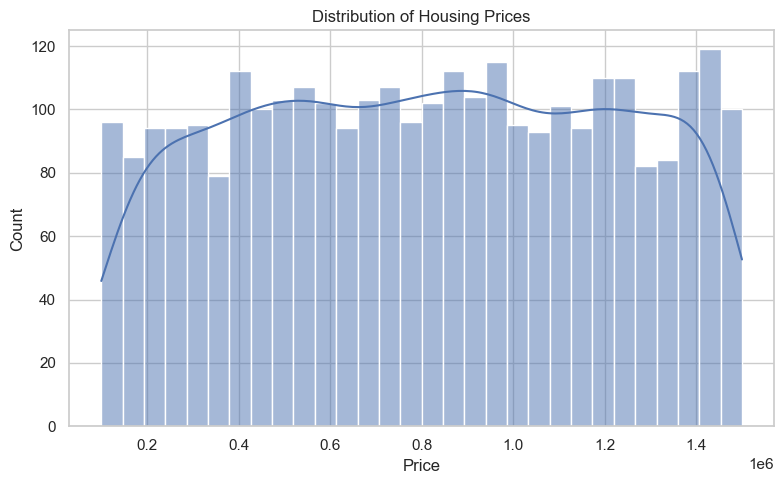

In [496]:
#Histogram of Housing Prices

plt.figure(figsize=(8,5))
sns.histplot(Housing_data["price"], bins=30, kde=True)
plt.title("Distribution of Housing Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Based on the above historgram, housing prices are right-skewed, which suggests that most homes fall within a moderate price range while a smaller number of high-priced properties create a long upper tail.

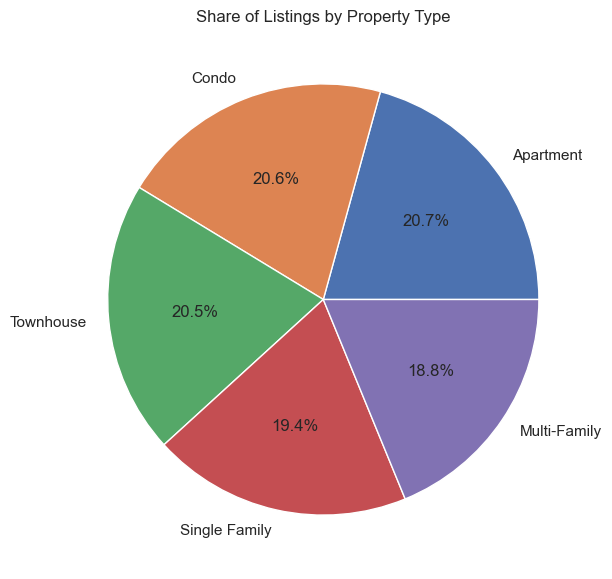

In [497]:
#Share of Listings by Property Type Using Pie Chart

Housing_data['property_type']. value_counts().plot(kind='pie',autopct='%1.1f%%',figsize=(7,7))

plt.title('Share of Listings by Property Type')
plt.ylabel('')
plt.show()

/var/folders/87/m6d_mt1s405875m53z71fdq40000gn/T/ipykernel_24014/2488870054.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_type = Housing_data.groupby('property_type')['price'].mean().sort_values()


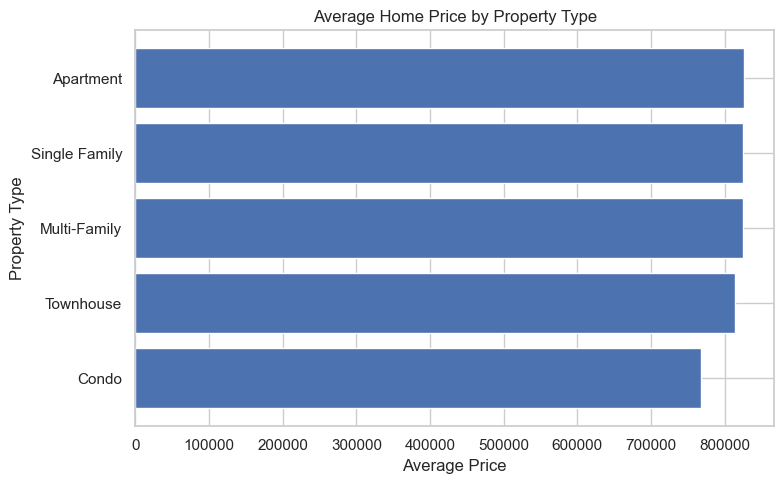

In [498]:
# Bar chart of average property prices by property type

avg_price_type = Housing_data.groupby('property_type')['price'].mean().sort_values()

plt.figure(figsize=(8,5))
plt.barh(avg_price_type.index, avg_price_type.values)
plt.xlabel('Average Price')
plt.ylabel('Property Type')
plt.title('Average Home Price by Property Type')
plt.tight_layout()
plt.show()

The Bar chart above compares average home prices across property types. A horizontal layout was used to improve label readability. The full price scale is shown to avoid exaggerating differences.

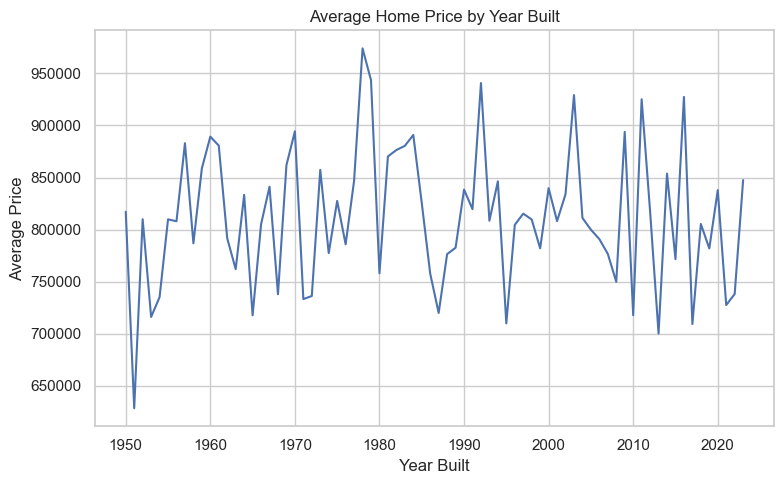

In [499]:
#Line chart of average home price by year built

price_by_year = Housing_data.groupby('year_built')['price'].mean()

plt.figure(figsize=(8,5))
plt.plot(price_by_year.index, price_by_year.values)
plt.xlabel('Year Built')
plt.ylabel('Average Price')
plt.title('Average Home Price by Year Built')
plt.tight_layout()
plt.show()

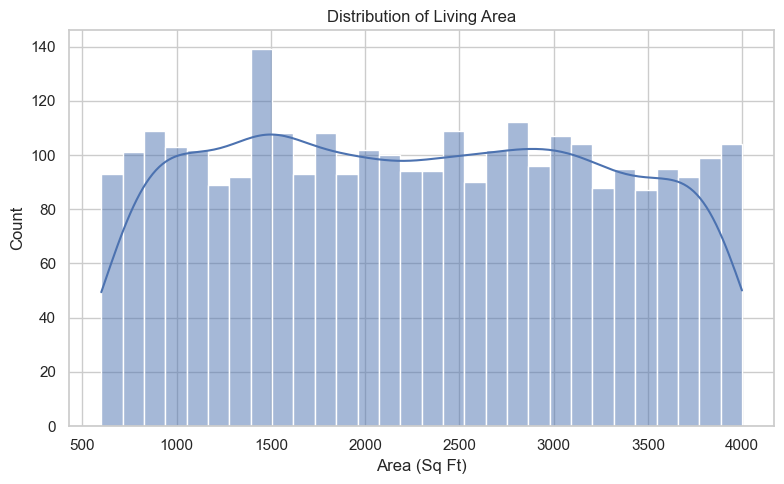

In [500]:
#Distribution of Living Area (sqft)

plt.figure(figsize=(8,5))
sns.histplot(Housing_data["area_sqft"], bins=30, kde=True)
plt.title("Distribution of Living Area")
plt.xlabel("Area (Sq Ft)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

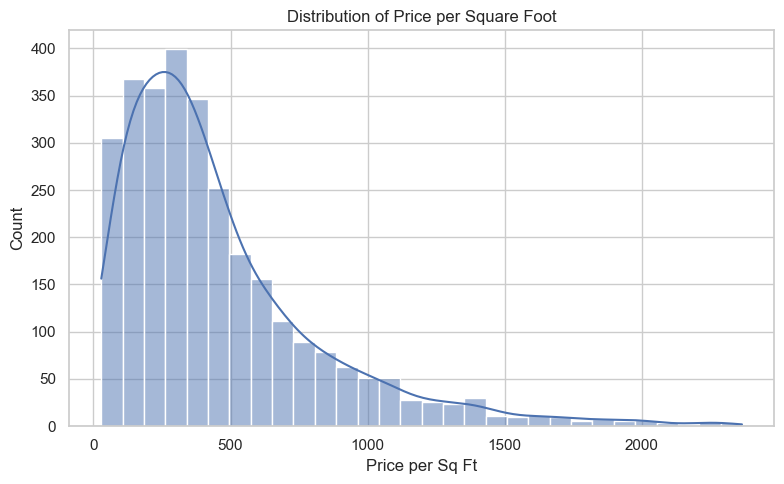

In [501]:
#Distribution of Prices Per sqft

plt.figure(figsize=(8,5))
sns.histplot(Housing_data["price_per_sqft"], bins=30, kde=True)
plt.title("Distribution of Price per Square Foot")
plt.xlabel("Price per Sq Ft")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

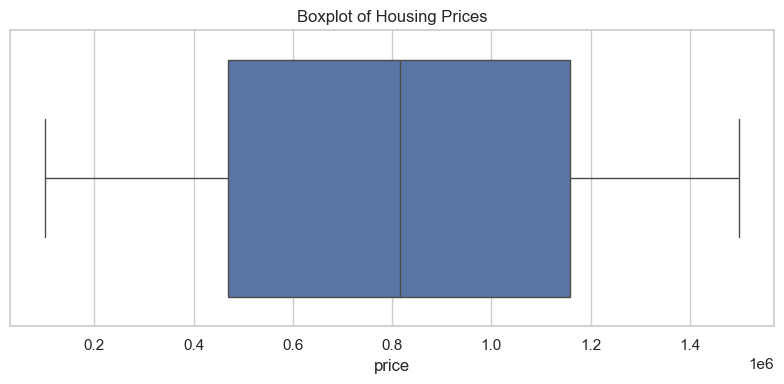

In [502]:
#Box Plot of housing price in general

plt.figure(figsize=(8,4))
sns.boxplot(x=Housing_data["price"])
plt.title("Boxplot of Housing Prices")
plt.tight_layout()
plt.show()

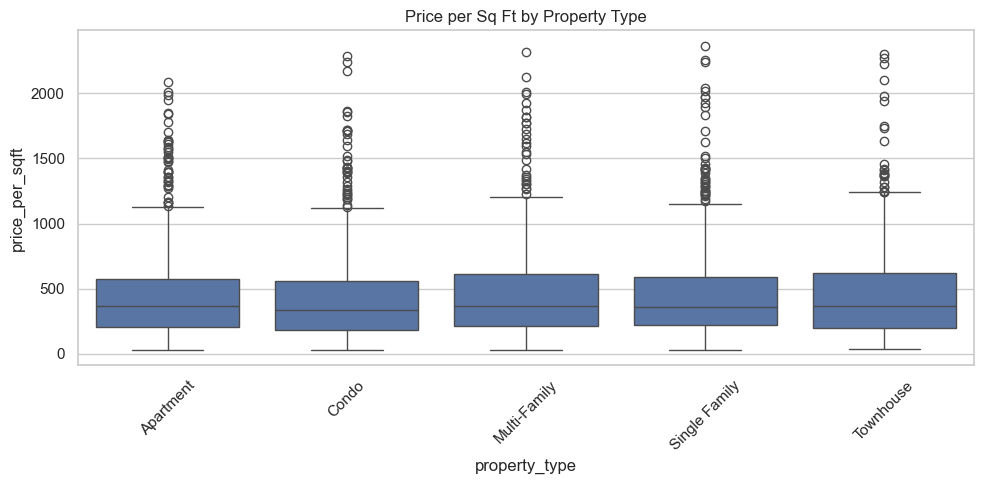

In [503]:
#Box Plot of Price per sqft by Property Type

plt.figure(figsize=(10,5))
sns.boxplot(data=Housing_data, x="property_type", y="price_per_sqft")
plt.xticks(rotation=45)
plt.title("Price per Sq Ft by Property Type")
plt.tight_layout()
plt.show()

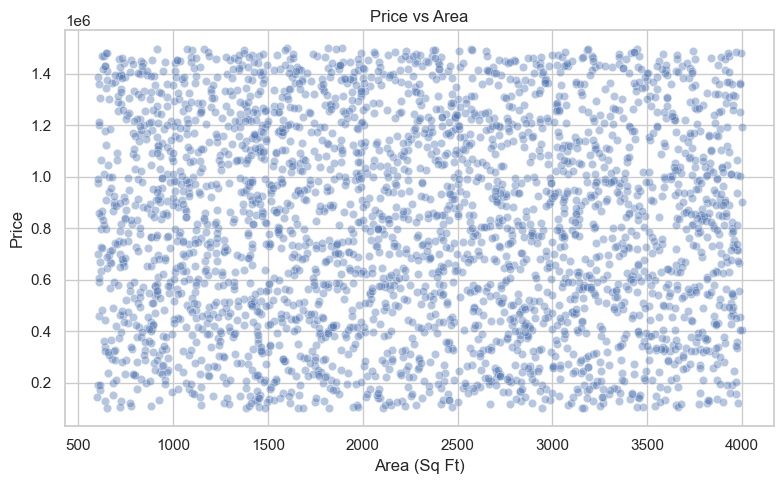

In [504]:
#Scatter Plot of Price Vs Area

plt.figure(figsize=(8,5))
sns.scatterplot(data=Housing_data, x="area_sqft", y="price", alpha=0.4)
plt.title("Price vs Area")
plt.xlabel("Area (Sq Ft)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

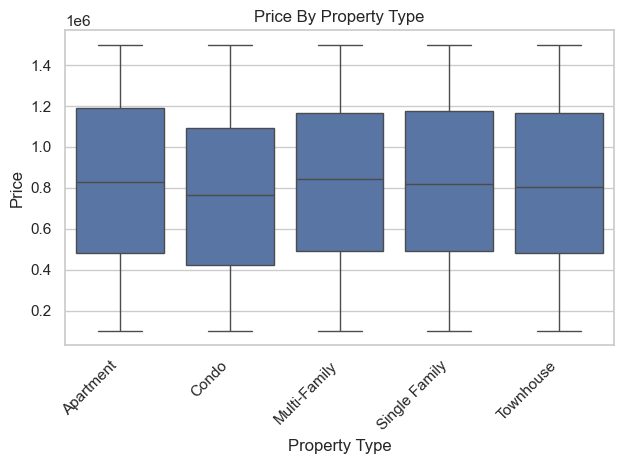

In [505]:
# Price By Property Type (Box Plot)

plt.Figure(figsize=(10,6))
sns.boxplot(data = Housing_data,
            x='property_type',
            y='price')
plt.xticks (rotation=45, ha='right')
plt.xlabel('Property Type')
plt.ylabel('Price')
plt.title('Price By Property Type')
plt.tight_layout()
plt.show()

/var/folders/87/m6d_mt1s405875m53z71fdq40000gn/T/ipykernel_24014/2415043778.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_cities = Housing_data.groupby("city")["price"].mean().sort_values(ascending=False).head(10)


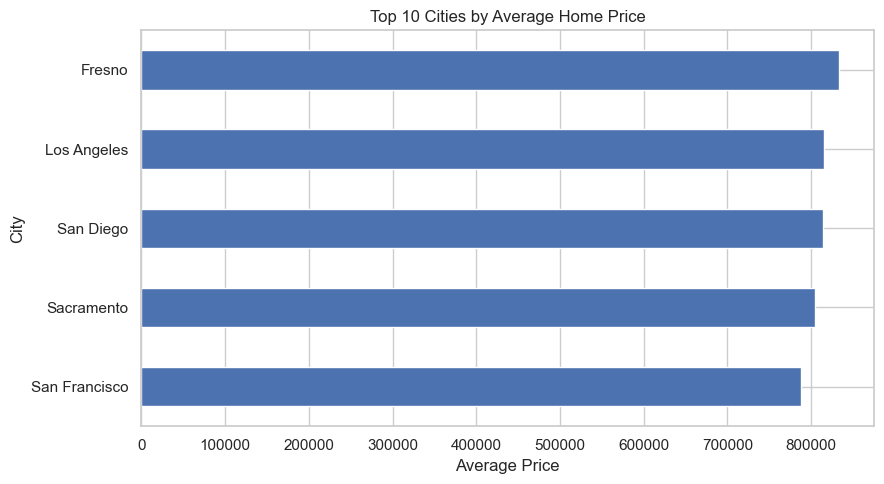

In [506]:
#Bar chart of average home price by city

top_cities = Housing_data.groupby("city")["price"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
top_cities.sort_values().plot(kind="barh")
plt.title("Top 10 Cities by Average Home Price")
plt.xlabel("Average Price")
plt.ylabel("City")
plt.tight_layout()
plt.show()

/var/folders/87/m6d_mt1s405875m53z71fdq40000gn/T/ipykernel_24014/888395706.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_price_by_state = Housing_data.groupby('state')['price'].mean().sort_index(ascending=False)


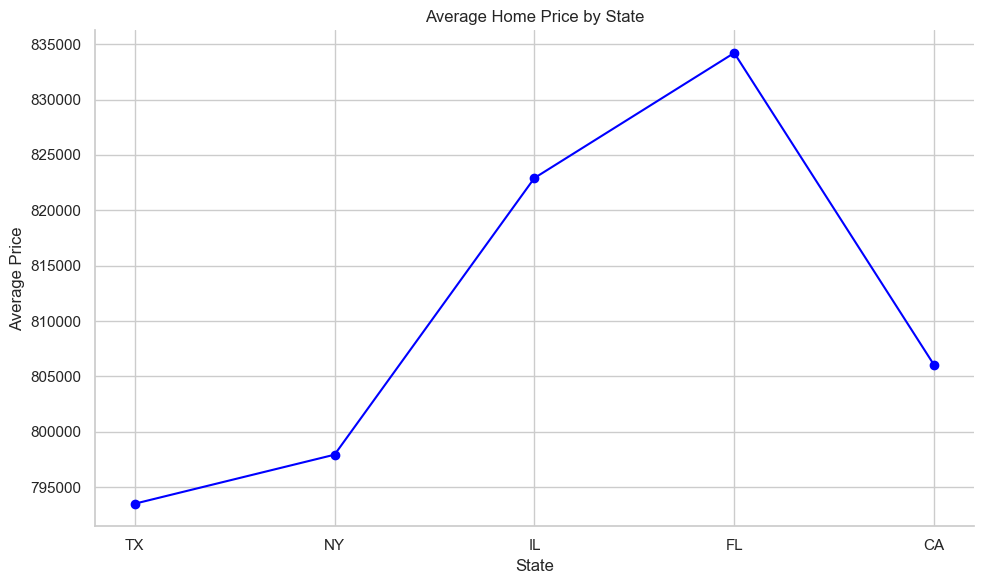

In [507]:
#Line Chart of Average Home Price by State

mean_price_by_state = Housing_data.groupby('state')['price'].mean().sort_index(ascending=False)

plt.figure(figsize=(10,6))
plt.plot(mean_price_by_state.index, mean_price_by_state.values, marker = 'o', color = 'blue')
plt.title('Average Home Price by State')
plt.xlabel('State')
plt.ylabel('Average Price')
ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

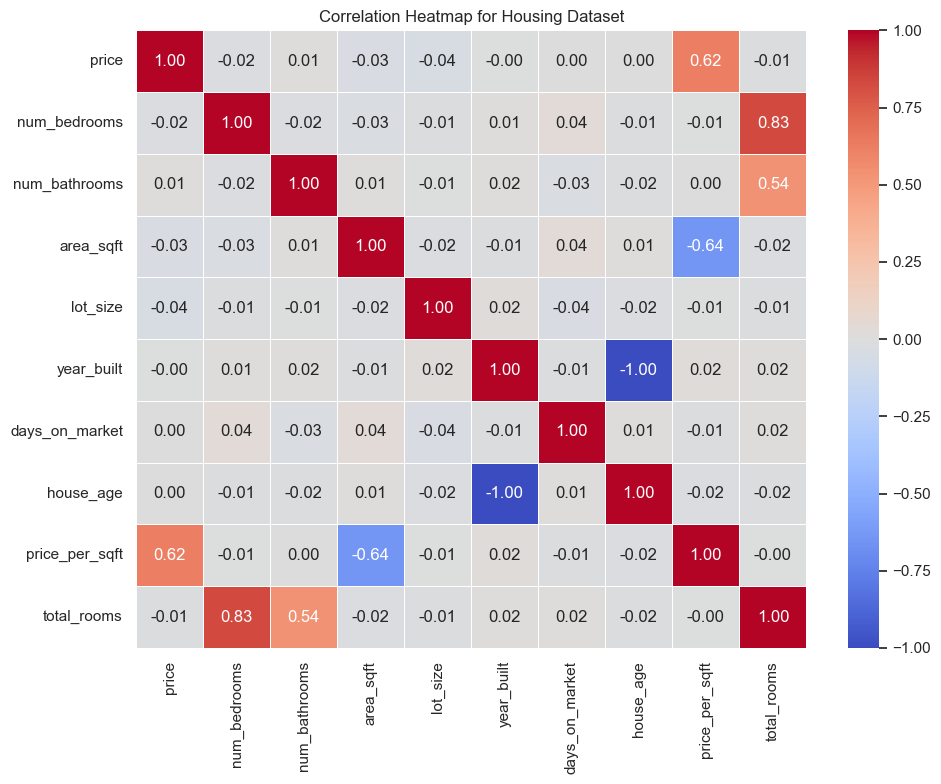

In [508]:
#Correlation Heatmap of Housing Dataset

housing_numeric = Housing_data.select_dtypes(include="number")

plt.figure(figsize=(10,8))
sns.heatmap(housing_numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Housing Dataset")
plt.tight_layout()
plt.show()

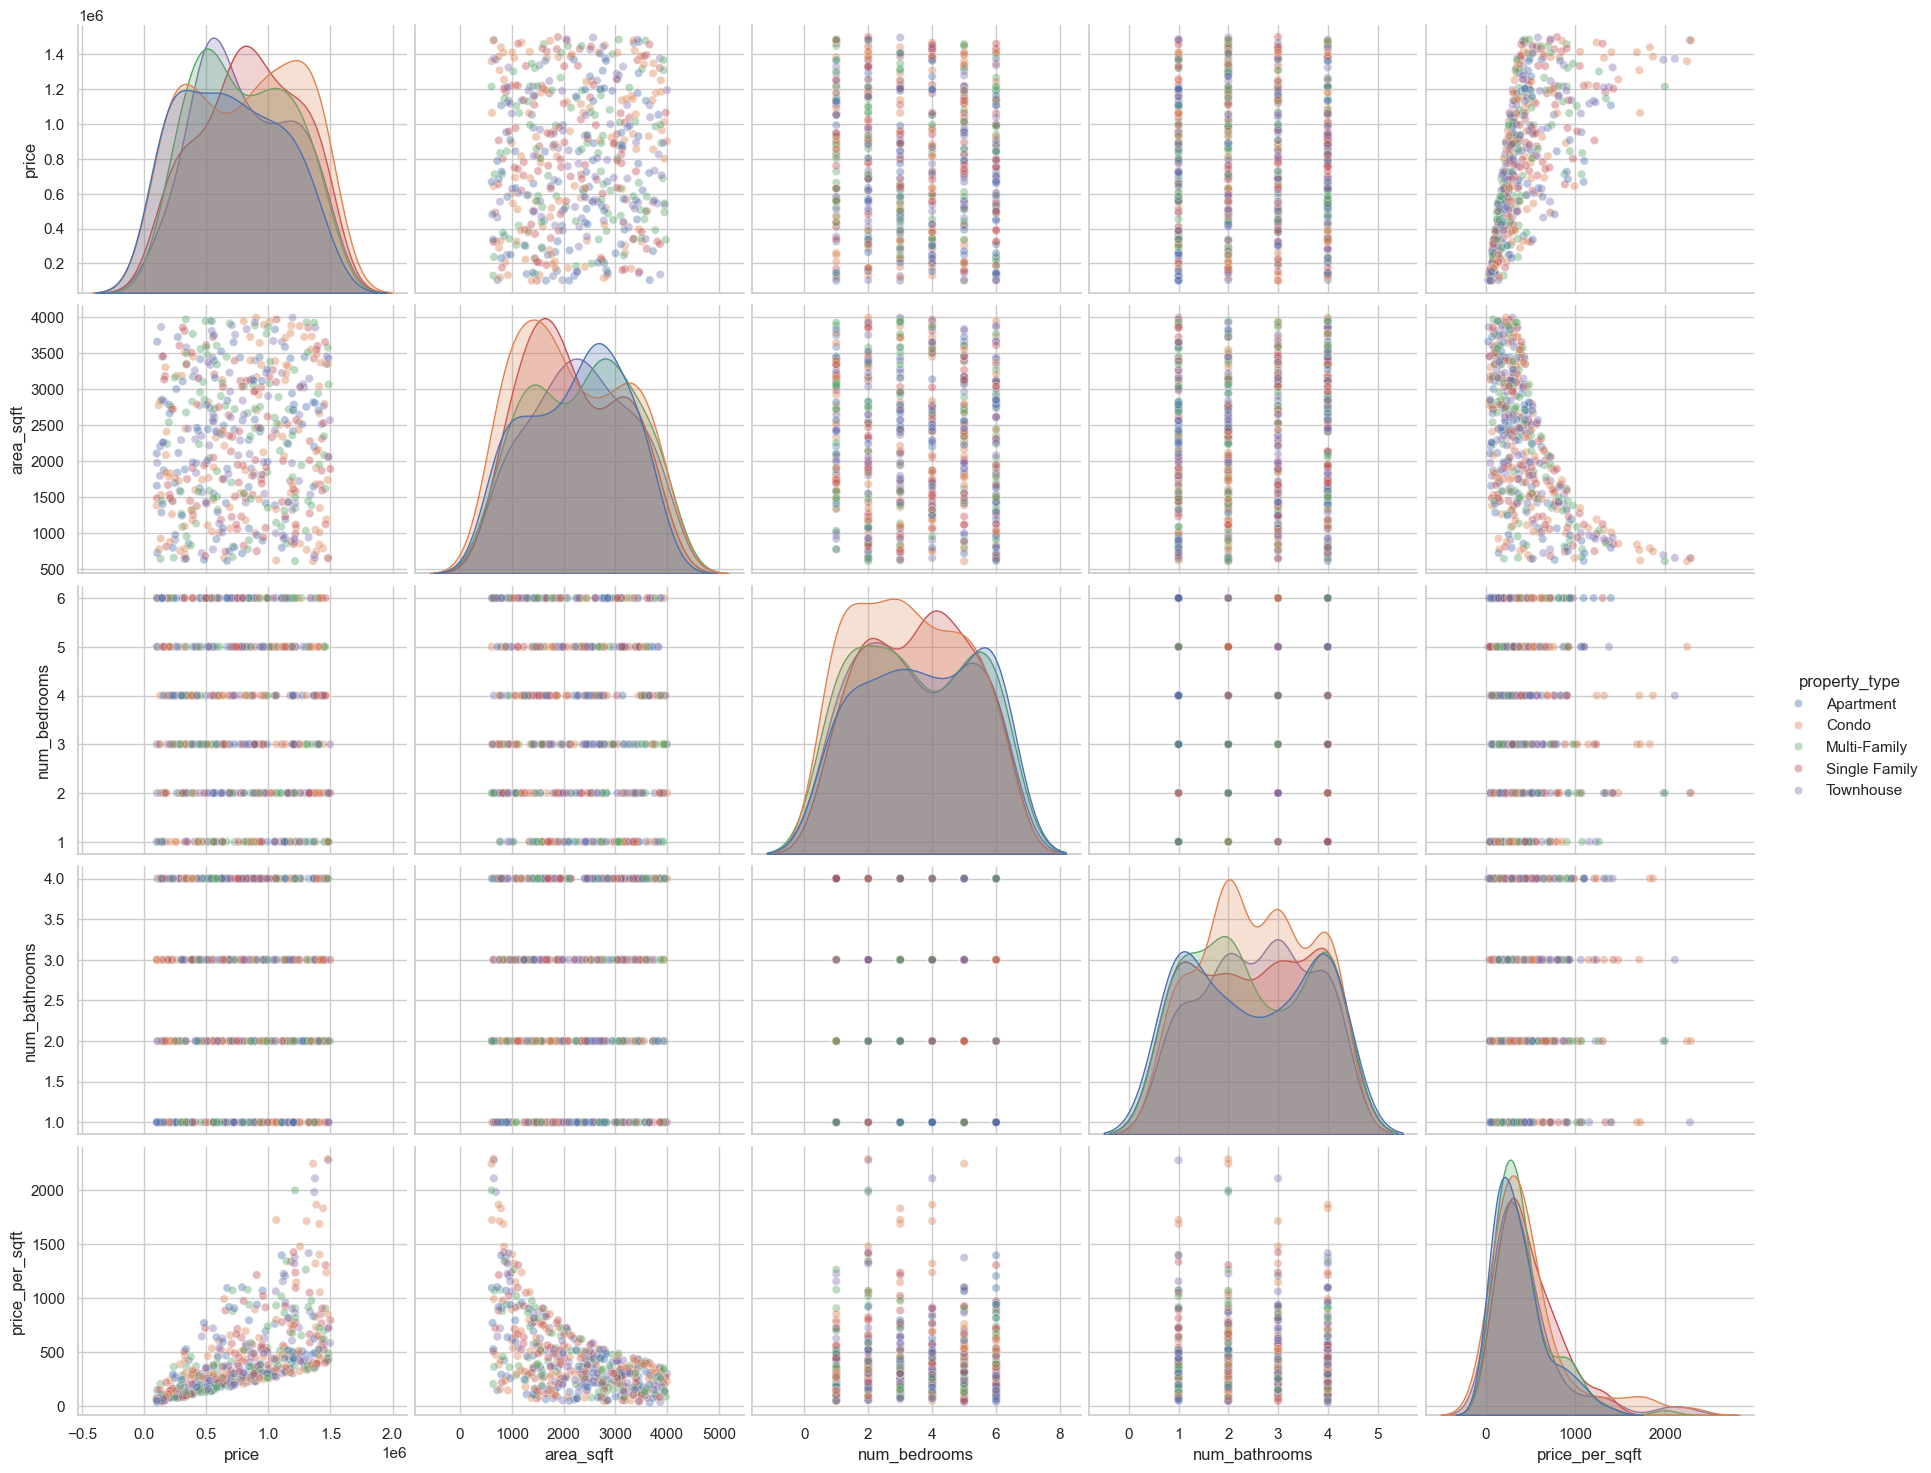

In [509]:
#Pair plot of Property types and influecing factors in their price

housing_sample = Housing_data[["price", "area_sqft", "num_bedrooms", "num_bathrooms", "price_per_sqft", "property_type"]].dropna().sample(500, random_state=42)

sns.pairplot(
    housing_sample,
    hue="property_type",
    height=3,
    aspect=1.2,
    diag_kind="kde",
    plot_kws={"alpha": 0.4}
)
plt.show()

### Housing Dataset EDA Summary

The housing dataset shows strong relationships between price, square footage, and bathrooms. Price per square foot varies meaningfully by property type, suggesting that home size alone does not fully explain value. There is also meaningful variation across cities, which hints that location likely plays an important role in pricing and should be explored further using external data.

### Section 2: Income Dataset Preview

This section focuses on the income dataset. Since this file contains tax-related information at the ZIP-code level, it must be cleaned carefully before it can be merged with the housing data.
This section focuses on analyzing the income dataset independently before merging it with housing data. The dataset contains ZIP-level income information, including the number of households and total adjusted gross income (AGI).
Understanding this dataset on its own will help identify patterns in income distribution across different ZIP codes and prepare it for integration with housing data.

In [510]:
income_data.head(10)

,STATEFIPS,STATE,ZIPCODE,agi_stub,N1,MARS1,MARS2,MARS4,ELF,CPREP,PREP,DIR_DEP,VRTCRIND,N2,TOTAL_VITA,VITA,TCE,VITA_EIC,RAC,ELDERLY,A00100,N02650,A02650,N00200,A00200,N00300,A00300,N00600,A00600,N00650,A00650,N00700,A00700,N00900,A00900,N01000,A01000,N01400,A01400,N01700,A01700,SCHF,N02300,A02300,N02500,A02500,N26270,A26270,N02900,A02900,N03220,A03220,N03300,A03300,N03270,A03270,N03150,A03150,N03210,A03210,N02910,A02910,N04450,A04450,N04100,A04100,N04200,A04200,N04470,A04470,A00101,N17000,A17000,N18425,A18425,N18450,A18450,N18500,A18500,N18800,A18800,N18460,A18460,N18300,A18300,N19300,A19300,N19500,A19500,N19530,A19530,N19550,A19550,N19570,A19570,N19700,A19700,N20950,A20950,N04475,A04475,N04800,A04800,N05800,A05800,N09600,A09600,N05780,A05780,N07100,A07100,N07300,A07300,N07180,A07180,N07230,A07230,N07240,A07240,N07225,A07225,N07260,A07260,N09400,A09400,N85770,A85770,N85775,A85775,N10600,A10600,N59660,A59660,N59720,A59720,N11070,A11070,N10960,A10960,N11560,A11560,N11450,A11450,N11520,A11520,N11530,A11530,N10970,A10970,N10971,A10971,N06500,A06500,N10300,A10300,N85530,A85530,N85300,A85300,N11901,A11901,N11900,A11900,N11902,A11902,N12000,A12000
0,1,AL,0,0,2108710.0,947310.0,739080.0,373380.0,1989930.0,58090.0,1155970.0,1457290.0,56840.0,4049130.0,27140.0,18770.0,8370.0,4510.0,452290.0,536010.0,154039634.0,2108690.0,1.553183e+08,1722780.0,97982581.0,562270.0,712279.0,295980.0,2610599.0,276810.0,1974937.0,57990.0,68580.0,392250.0,4248671.0,301520.0,13017892.0,184680.0,4130358.0,439250.0,12113450.0,39180.1543,98850.0,795919.0,342280.0,5597361.0,91950.0,10973359.0,417360.0,1278658.0,41930.0,10932.0,5010.0,142722.0,33060.0,278689.0,20670.0,104198.0,48950.0,43426.0,729930.0,287409.0,1957890.0,35414547.0,1957820.0,34684941.0,355410.0,726135.0,147550.0,6050667.0,42021004.0,37720.0,577341.0,117480.0,1309325.0,20080.0,36130.0,117380.0,324355.0,91920.0,42592.0,143700.0,930705.0,144630.0,955875.0,103540.0,997677.0,430.0,3908.0,4680.0,3463.0,9550.0,16253.0,5510.0,58293.0,129680.0,2859374.0,8290.0,204748.0,266290.0,2210973.0,1650330.0,112578826.0,1644960.0,19490683.0,760.0,10057.0,26790.0,36518.0,495330.0,517102.0,80060.0,106992.0,3150.0,4872.0,116100.0,121465.0,152400.0,30078.0,170960.0,114920.0,34330.0,44080.0,278770.0,843420.0,113340.0,975879.0,118140.0,1004984.0,2024510.0,23368079.0,579260.0,1361421.0,479570.0,1076591.0,581740.0,1796745.0,98370.0,87198.0,50990.0,35844.0,25660.0,87289.0,118550.0,266580.0,24360.0,95437.0,159910.0,271684.0,1751350.0,4965629.0,1570330.0,18916060.0,1678750.0,20297213.0,40130.0,70014.0,54580.0,319155.0,459450.0,3101895.0,1598820.0,6196854.0,1570090.0,5503283.0,31140.0,629844.0
1,1,AL,35004,0,5360.0,2430.0,2000.0,760.0,5100.0,130.0,2490.0,3750.0,190.0,10140.0,20.0,0.0,20.0,0.0,1020.0,1320.0,349377.0,5360.0,3.514980e+05,4540.0,276443.0,1400.0,844.0,680.0,1693.0,610.0,929.0,180.0,207.0,840.0,7602.0,650.0,10571.0,470.0,7791.0,1030.0,22766.0,0.0000,170.0,1472.0,800.0,11926.0,160.0,8894.0,980.0,2121.0,120.0,30.0,0.0,0.0,50.0,343.0,70.0,240.0,180.0,158.0,2070.0,785.0,4990.0,91405.0,4990.0,89599.0,900.0,1806.0,360.0,10003.0,47542.0,90.0,1256.0,320.0,1733.0,30.0,60.0,280.0,306.0,240.0,66.0,340.0,1860.0,340.0,1894.0,260.0,1853.0,0.0,0.0,0.0,0.0,50.0,63.0,0.0,0.0,320.0,4297.0,0.0,0.0,570.0,2793.0,4500.0,249901.0,4480.0,35874.0,0.0,0.0,80.0,98.0,1180.0,994.0,120.0,5.0,30.0,41.0,290.0,306.0,400.0,73.0,430.0,289.0,90.0,131.0,580.0,1575.0,260.0,2337.0,280.0,2380.0,5150.0,44561.0,1000.0,2092.0,780.0,1569.0,1450.0,4350.0,200.0,163.0,120.0,86.0,30.0,69.0,340.0,715.0,30.0,67.0,350.0,555.0,4630.0,13113.0,4350.0,34863.0,4510.0,36897.0,50.0,34.0,50.0,223.0,1270.0,4626.0,3940.0,11948.0,3900.0,11353.0,60.0,189.0
2,1,AL,35005,0,3190.0,1500.0,730.0,890.0,3040.0,70.0,1680.0,2480.0,40.0,5870.0,30.0,30.0,0.0,0.0,1010.0,730.0,135558.0,3190.0,1.363390e+05,2710.0,108856.0,500.0,239.0,180.0,259.0,160.0,127.0,70.0,56.0,600.0,1094.0,160.0,744.0,200.0,2599.0,610.0,13282.0,0.0000,180.0,1559.0,450.0,5412.0,30.0,143.0,480.0,781.0,50.0,12.0,0.0,0.0,0.0,

In [511]:
income_data.shape

(27705, 167)

In [512]:
income_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27705 entries, 0 to 27704
Columns: 167 entries, STATEFIPS to A12000
dtypes: float64(163), int64(3), object(1)
memory usage: 35.3+ MB


In [513]:
income_data.describe()

,STATEFIPS,ZIPCODE,agi_stub,N1,MARS1,MARS2,MARS4,ELF,CPREP,PREP,DIR_DEP,VRTCRIND,N2,TOTAL_VITA,VITA,TCE,VITA_EIC,RAC,ELDERLY,A00100,N02650,A02650,N00200,A00200,N00300,A00300,N00600,A00600,N00650,A00650,N00700,A00700,N00900,A00900,N01000,A01000,N01400,A01400,N01700,A01700,SCHF,N02300,A02300,N02500,A02500,N26270,A26270,N02900,A02900,N03220,A03220,N03300,A03300,N03270,A03270,N03150,A03150,N03210,A03210,N02910,A02910,N04450,A04450,N04100,A04100,N04200,A04200,N04470,A04470,A00101,N17000,A17000,N18425,A18425,N18450,A18450,N18500,A18500,N18800,A18800,N18460,A18460,N18300,A18300,N19300,A19300,N19500,A19500,N19530,A19530,N19550,A19550,N19570,A19570,N19700,A19700,N20950,A20950,N04475,A04475,N04800,A04800,N05800,A05800,N09600,A09600,N05780,A05780,N07100,A07100,N07300,A07300,N07180,A07180,N07230,A07230,N07240,A07240,N07225,A07225,N07260,A07260,N09400,A09400,N85770,A85770,N85775,A85775,N10600,A10600,N59660,A59660,N59720,A59720,N11070,A11070,N10960,A10960,N11560,A11560,N11450,A11450,N11520,A11520,N11530,A11530,N10970,A10970,N10971,A10971,N06500,A06500,N10300,A10300,N85530,A85530,N85300,A85300,N11901,A11901,N11900,A11900,N11902,A11902,N12000,A12000
count,27705.000000,27705.000000,27705.0,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,27705.000000,2.770500e+04,2.770500e+04,27705.000000,2.770500e+04,27705.000000,27705.000000,27705.000000,27705.000000,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,27705.000000,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,27705.000000,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,27705.000000,27705.000000,27705.000000,2.770500e+04,27705.000000,2.770500e+04,27705.000000,2.770500e+04,27705.000000,27705.000000,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,27705.000000,2.770500e+04,2.770500e+04,2.770500e+04,27705.000000,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,27705.000000,27705.000000,27705.000000,27705.000000,27705.000000,27705.000000,27705.000000,2.770500e+04,2.770500e+04,2.770500e+04,27705.000000,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,27705.000000,2.770500e+04,27705.000000,27705.000000,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,27705.000000,27705.000000,27705.000000,27705.000000,27705.000000,27705.000000,2.770500e+04,2.770500e+04,27705.000000,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,27705.000000,27705.000000,27705.000000,27705.000000,27705.000000,27705.000000,27705.000000,2.770500e+04,27705.000000,27705.000000,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,2.770500e+04,27705.000000,2.770500e+04
mean,29.664645,48878.105757,0.0,1.120607e+04,5.610174e+03,3.844394e+03,1.485928e+03,1.052511e+04,368.495578,5.958003e+03,7.244105e+03,461.144920,2.063661e+04,141.284606,83.467605,57.817001,22.739939,1.658980e+03,2.871698e+03,1.062678e+06,1.120597e+04,1.072275e+06,9.021924e+03,6.433355e+05,3.433623e+03,6.250135e+03,2.263396e+03,2.523457e+04,2.147603e+03,1.886937e+04,219.322866,2.361531e+02,2.019807e+03,3.055788e+04,2.319184e+03,1.320747e+05,1.113825e+03,2.859029e+04,2.086175e+03,6.081426e+04,111.914529,1.106604e+03,1.456227e+04,1.700062e+03,2.971581e+04,6.264866e+02,7.128985e+04,2.337830e+03,9.596529e+03,212.478975,55.541671,62.612886,1.883491e+03,241.366179,2.016738e+03,154.185887

In [514]:
income_data.isnull().sum() * 100 / len(income_data)

STATEFIPS    0.0
STATE        0.0
ZIPCODE      0.0
agi_stub     0.0
N1           0.0
            ... 
A11900       0.0
N11902       0.0
A11902       0.0
N12000       0.0
A12000       0.0
Length: 167, dtype: float64

In [515]:
income_data.duplicated().sum()

np.int64(0)

In [516]:
#changing the zipcode data type to fully match the housing dataset
income_data['ZIPCODE'] = pd.to_numeric(income_data['ZIPCODE'], errors='coerce').fillna(0).astype('int64')

#Filter out 'ZIPCODE 0' and select 4 columns
income_filtered = income_data[income_data['ZIPCODE'] != 0].copy()
income_subset = income_filtered[['STATE', 'ZIPCODE', 'N1', 'A00100']]

#Renaming to snake case for better consistency with the first dataset
income_subset = income_subset.rename(columns={
    'STATE': 'state_code',
    'ZIPCODE': 'zip_code',
    'N1': 'household_count',
    'A00100': 'total_agi_thousands'
})
#changing the data type of household_count to integer is better for avoiding noise
income_subset['household_count'] = income_subset['household_count'].astype(int)
income_subset.head()

,state_code,zip_code,household_count,total_agi_thousands
1,AL,35004,5360,349377.0
2,AL,35005,3190,135558.0
3,AL,35006,1260,72991.0
4,AL,35007,12250,819565.0
5,AL,35010,8130,567026.0


### Refining the Economic Grain: Bracket Aggregation
The raw IRS dataset presents a challenge: it classifies income into six distinct brackets per Zip Code. To perform a relational join with our property listings, we must resolve this into a 1:1 relationship.

#### The Process:

* Aggregation: I utilized a groupby operation on the zip_code attribute to consolidate the six rows.

* Metric Generation: By summing the total Adjusted Gross Income (AGI) and the total number of households (N1), I calculated a Weighted Average Income for each neighborhood.

* Result: This transforms fragmented tax data into a singular Economic Anchor that can be accurately mapped to each residential asset in our primary dataset.

In [517]:
#First, group by zip_code and sum the totals
income_grouped = income_subset.groupby(['state_code', 'zip_code']).agg({
    'household_count': 'sum',
    'total_agi_thousands': 'sum'
}).reset_index()

income_grouped.head()

,state_code,zip_code,household_count,total_agi_thousands
0,AK,99501,7690,716764.0
1,AK,99502,11650,1142673.0
2,AK,99503,7360,519561.0
3,AK,99504,19150,1276865.0
4,AK,99505,2210,111578.0


In [518]:
#Note: 'total_agi_thousands' is in thousands of dollars, so we multiply by 1000

income_grouped['avg_household_income'] = ((income_grouped['total_agi_thousands'] * 1000) / income_grouped['household_count']).round(0)

income_grouped[['zip_code', 'avg_household_income']].round(0).head()

,zip_code,avg_household_income
0,99501,93207.0
1,99502,98084.0
2,99503,70593.0
3,99504,66677.0
4,99505,50488.0


In [519]:
income_subset.isnull().sum()

state_code             0
zip_code               0
household_count        0
total_agi_thousands    0
dtype: int64

In [520]:
income_subset.head()

,state_code,zip_code,household_count,total_agi_thousands
1,AL,35004,5360,349377.0
2,AL,35005,3190,135558.0
3,AL,35006,1260,72991.0
4,AL,35007,12250,819565.0
5,AL,35010,8130,567026.0


In [521]:
income_subset.describe().T

,count,mean,std,min,25%,50%,75%,max
zip_code,27654.0,48968.247631,2.711443e+04,1001.0,27242.25,48891.5,70714.75,99999.0
household_count,27654.0,5614.709264,7.992662e+03,90.0,600.00,2010.0,8160.00,338520.0
total_agi_thousands,27654.0,532319.060787,1.047054e+06,1517.0,37561.50,136801.5,624609.75,42367010.0


### Univariate Analysis

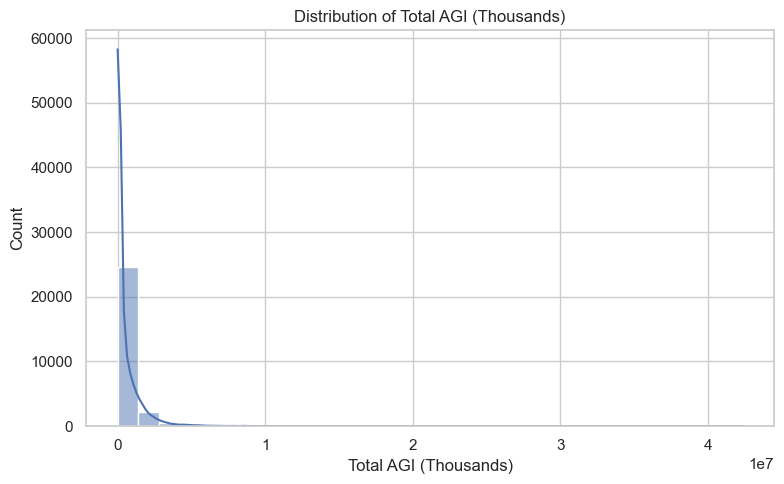

In [522]:
#Distribution — Total AGI (Thousands)

plt.figure(figsize=(8,5))
sns.histplot(income_subset["total_agi_thousands"], bins=30, kde=True)
plt.title("Distribution of Total AGI (Thousands)")
plt.xlabel("Total AGI (Thousands)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Total AGI is right-skewed, indicating that most ZIP codes have moderate total income levels, while a smaller number of ZIP codes have significantly higher total income.

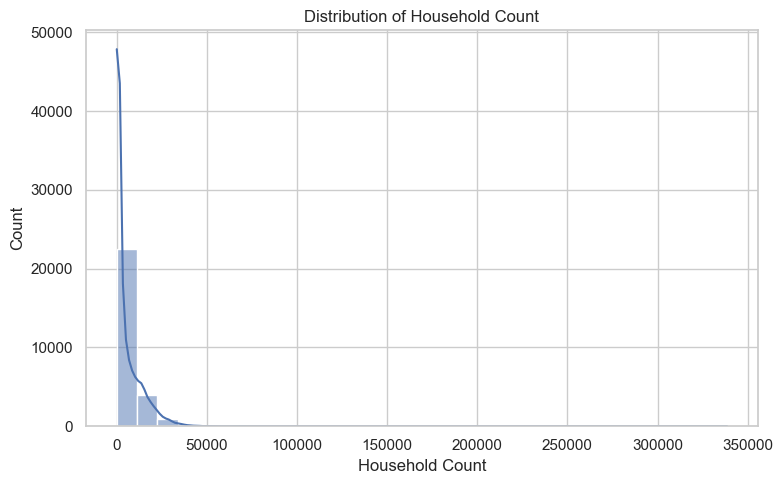

In [523]:
#Distribution — Household Count

plt.figure(figsize=(8,5))
sns.histplot(income_subset["household_count"], bins=30, kde=True)
plt.title("Distribution of Household Count")
plt.xlabel("Household Count")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Household counts vary widely across ZIP codes, reflecting differences in population density across regions.

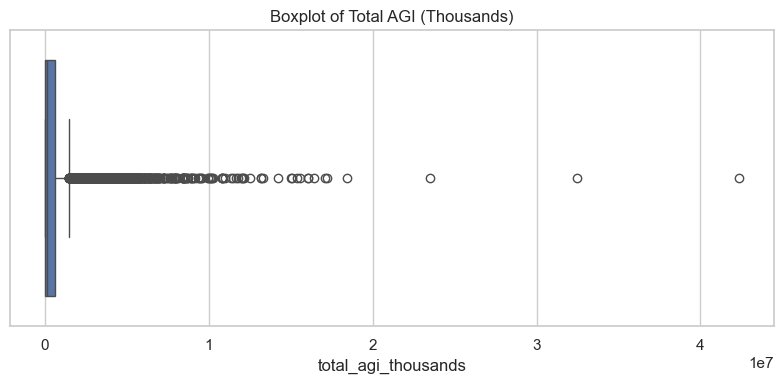

In [524]:
#Boxplot — Total AGI

plt.figure(figsize=(8,4))
sns.boxplot(x=income_subset["total_agi_thousands"])
plt.title("Boxplot of Total AGI (Thousands)")
plt.tight_layout()
plt.show()

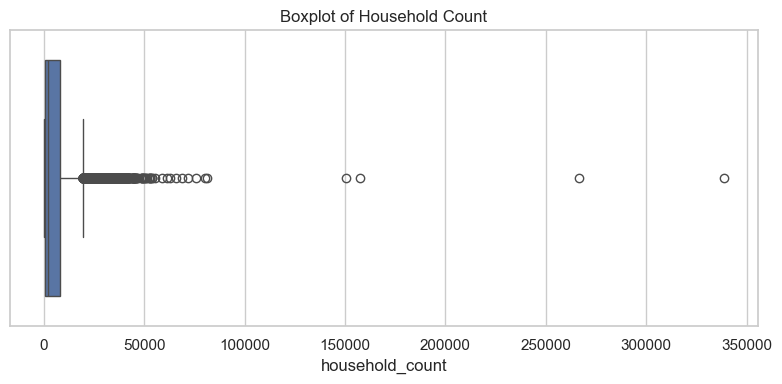

In [525]:
#Boxplot — Household Count

plt.figure(figsize=(8,4))
sns.boxplot(x=income_subset["household_count"])
plt.title("Boxplot of Household Count")
plt.tight_layout()
plt.show()

Both total AGI and household count show outliers, suggesting that some ZIP codes represent significantly larger or wealthier populations than others.

### Ranking & Comparison

In [526]:
#Top Zip codes by total agi

top_agi = income_subset.sort_values(
    by="total_agi_thousands", ascending=False
).head(10)

top_agi[["zip_code", "total_agi_thousands"]]

,zip_code,total_agi_thousands
2893,99999,42367010.0
24660,99999,32473171.0
17461,99999,23486142.0
2290,94301,18452741.0
4556,99999,17196246.0
15968,10128,17072506.0
15944,10021,16426246.0
4183,33480,16047060.0
15945,10022,16043467.0
15946,10023,15548171.0


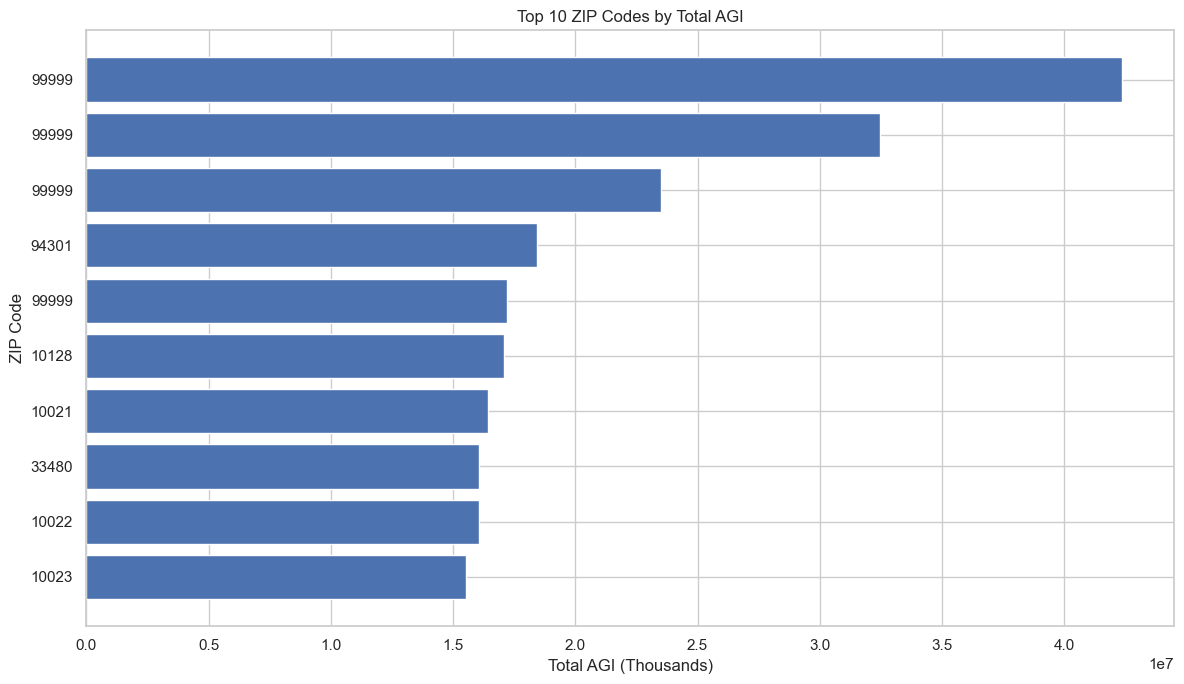

In [527]:
#Top 10 ZIP Codes by Total AGI

plt.figure(figsize=(12, 7))

sorted_data = top_agi.sort_values("total_agi_thousands", ascending=True)

plt.barh(
    y=range(len(sorted_data)),
    width=sorted_data["total_agi_thousands"]
)

plt.yticks(range(len(sorted_data)), sorted_data["zip_code"])

plt.title("Top 10 ZIP Codes by Total AGI")
plt.xlabel("Total AGI (Thousands)")
plt.ylabel("ZIP Code")

plt.tight_layout()
plt.show()

In [528]:
#Bottom zip codes by total agi

bottom_agi = income_subset.sort_values(
    by="total_agi_thousands"
).head(10)

bottom_agi[["zip_code", "total_agi_thousands"]]

,zip_code,total_agi_thousands
7214,47406,1517.0
13606,64147,1584.0
22407,57658,2314.0
18403,58705,2342.0
436,36481,2763.0
27115,53706,2794.0
13303,63140,2873.0
14204,59444,2912.0
25544,23708,3067.0
1139,72175,3225.0


In [529]:
#Bottom zip codes

bottom_agi = income_subset.sort_values(
    by="total_agi_thousands"
).head(10)

bottom_agi[["zip_code", "total_agi_thousands"]]

,zip_code,total_agi_thousands
7214,47406,1517.0
13606,64147,1584.0
22407,57658,2314.0
18403,58705,2342.0
436,36481,2763.0
27115,53706,2794.0
13303,63140,2873.0
14204,59444,2912.0
25544,23708,3067.0
1139,72175,3225.0


### Bivariate Analysis

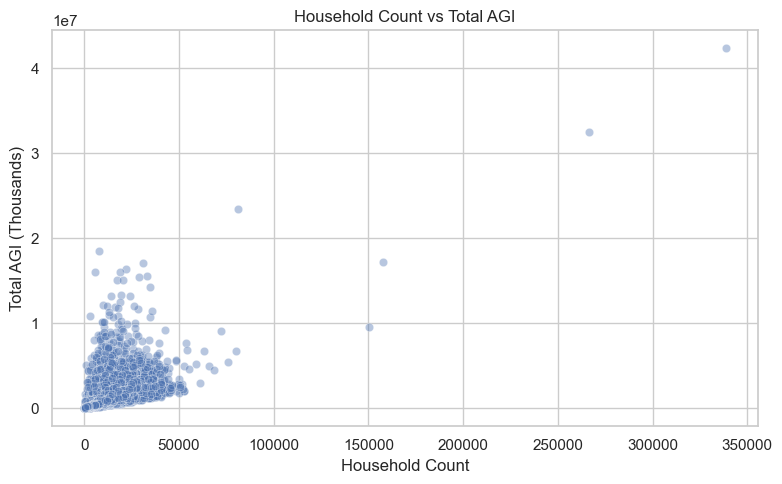

In [530]:
#Household Count vs Total AGI

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=income_subset,
    x="household_count",
    y="total_agi_thousands",
    alpha=0.4
)
plt.title("Household Count vs Total AGI")
plt.xlabel("Household Count")
plt.ylabel("Total AGI (Thousands)")
plt.tight_layout()
plt.show()

There is a strong positive relationship between household count and total AGI, indicating that ZIP codes with more households tend to generate higher total income.

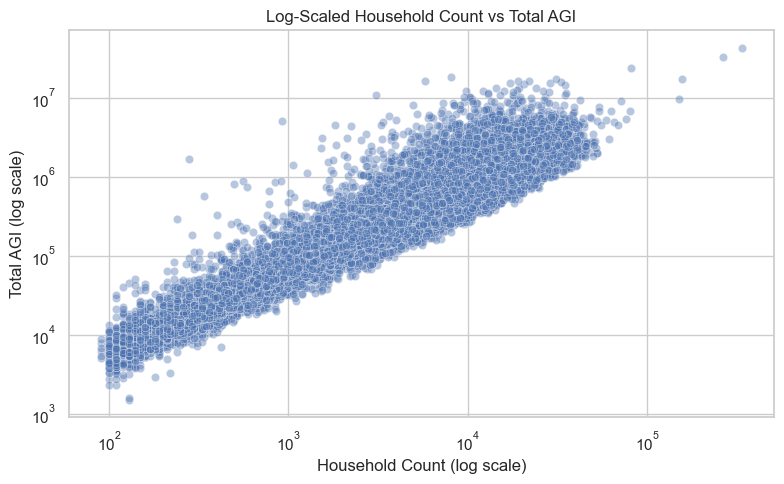

In [531]:
#Log-scale Scatter(Better Insight)

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=income_subset,
    x="household_count",
    y="total_agi_thousands",
    alpha=0.4
)
plt.xscale("log")
plt.yscale("log")
plt.title("Log-Scaled Household Count vs Total AGI")
plt.xlabel("Household Count (log scale)")
plt.ylabel("Total AGI (log scale)")
plt.tight_layout()
plt.show()

Using a log scale reveals a more linear relationship, confirming that total AGI scales proportionally with the number of households across ZIP codes.

### State-Level Analysis

In [532]:
#Aggregate by State

state_summary = income_subset.groupby("state_code")[[
    "household_count", "total_agi_thousands"
]].sum()

state_summary.head()

,household_count,total_agi_thousands
state_code,,
AK,343140,2.936915e+07
AL,2110040,1.540396e+08
AR,1269610,9.981543e+07
AZ,3289330,2.853478e+08
CA,18380840,2.133550e+09


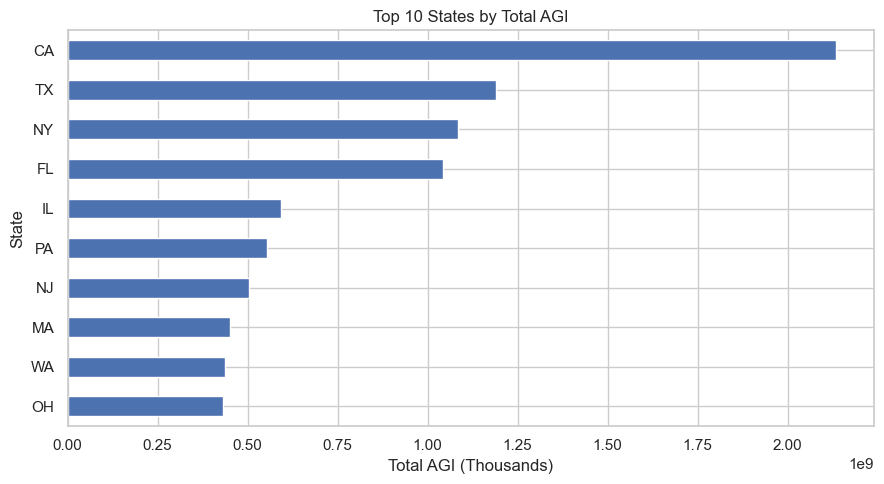

In [533]:
#Plot — Total AGI by State

top_states = state_summary.sort_values(
    by="total_agi_thousands", ascending=False
).head(10)

plt.figure(figsize=(9,5))
top_states["total_agi_thousands"].sort_values().plot(kind="barh")
plt.title("Top 10 States by Total AGI")
plt.xlabel("Total AGI (Thousands)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

States with larger populations tend to have higher total AGI, reflecting broader economic scale rather than individual wealth.

### Correlation Analysis

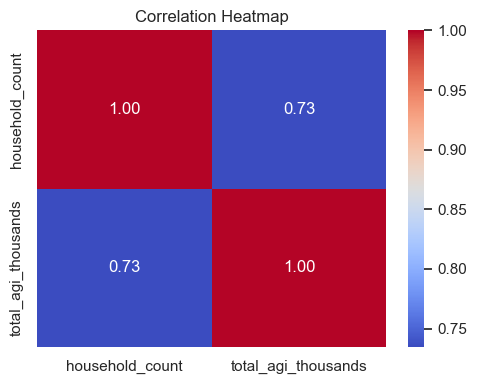

In [534]:
#Correlation Heatmap

numeric_cols = income_subset[[
    "household_count",
    "total_agi_thousands"
]]

plt.figure(figsize=(5,4))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Household count and total AGI are strongly correlated, confirming that total income is largely driven by population size.

### Income Dataset EDA Summary

The income dataset shows that total AGI is heavily influenced by the number of households within each ZIP code. Areas with larger populations naturally generate higher total income.

The distribution of both variables is highly skewed, indicating the presence of large economic disparities across ZIP codes. This dataset provides a strong foundation for further analysis, particularly when combined with housing data to understand affordability and pricing patterns.

### Section 3: Combining Housing and Income Datasets with SQLite

In this section, the housing dataset is combined with ZIP-level income data using SQLite and a left join. This allows each property listing to be enriched with local economic context, making it possible to explore affordability, pricing patterns, and the relationship between neighborhood income and housing value.

In [535]:
#Aggregate Income by ZIP

income_grouped = income_subset.groupby(["zip_code", "state_code"], as_index=False).agg({
    "household_count": "sum",
    "total_agi_thousands": "sum"
})

income_grouped.head()

,zip_code,state_code,household_count,total_agi_thousands
0,1001,MA,9030,630065.0
1,1002,MA,9720,1077501.0
2,1005,MA,2500,184554.0
3,1007,MA,7990,696127.0
4,1008,MA,620,50855.0


### Aggregating Income Data by ZIP Code

The income dataset contains ZIP-level tax information. To prepare it for integration with housing listings, the data is grouped so that each ZIP code has one summary row with total household count and total adjusted gross income.

In [536]:
#Create Average Income

income_grouped["avg_household_income"] = (
    income_grouped["total_agi_thousands"] * 1000
) / income_grouped["household_count"]

income_grouped["avg_household_income"] = income_grouped["avg_household_income"].round(0)

income_grouped.head()

,zip_code,state_code,household_count,total_agi_thousands,avg_household_income
0,1001,MA,9030,630065.0,69775.0
1,1002,MA,9720,1077501.0,110854.0
2,1005,MA,2500,184554.0,73822.0
3,1007,MA,7990,696127.0,87125.0
4,1008,MA,620,50855.0,82024.0


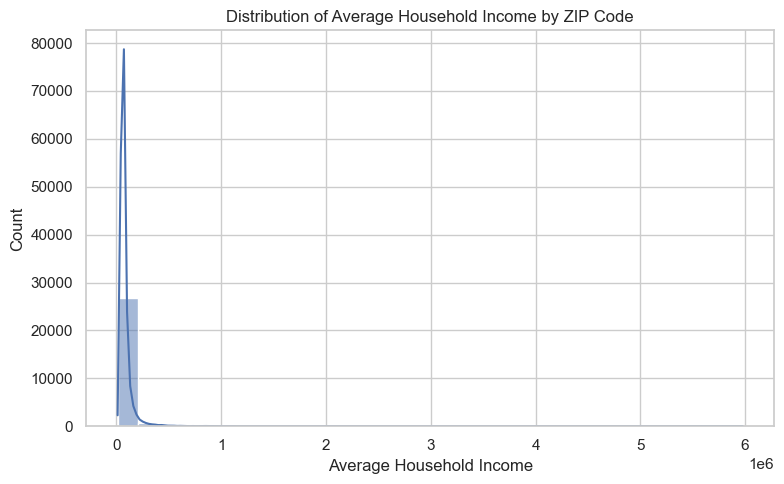

In [537]:
#Income Distribution

plt.figure(figsize=(8,5))
sns.histplot(income_grouped["avg_household_income"], bins=30, kde=True)
plt.title("Distribution of Average Household Income by ZIP Code")
plt.xlabel("Average Household Income")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Average household income varies across ZIP codes, with most areas falling within a moderate range and a smaller number of ZIP codes showing significantly higher income levels.

In [538]:
#SQLite Integration 

conn = sqlite3.connect("housing_analysis.db")

Housing_data.to_sql("property_listings", conn, if_exists="replace", index=False)
income_grouped.to_sql("neighborhood_income", conn, if_exists="replace", index=False)

query = """
SELECT
    h.*,
    i.state_code,
    i.household_count,
    i.total_agi_thousands,
    i.avg_household_income
FROM property_listings h
LEFT JOIN neighborhood_income i
    ON CAST(h.zipcode AS INTEGER) = i.zip_code
"""

master_df = pd.read_sql(query, conn)

master_df.head()

,price,address,city,zipcode,state,num_bedrooms,num_bathrooms,area_sqft,lot_size,year_built,days_on_market,property_type,status,house_age,price_per_sqft,total_rooms,price_band,state_code,household_count,total_agi_thousands,avg_household_income
0,554217,"5926 Oak Ave, San Diego, CA 65383",San Diego,65383,CA,1,3.0,772,4757,1959,101,Townhouse,For Sale,67,717.897668,4.0,Mid-Low,None,NaN,NaN,NaN
1,164454,"9583 Oak Ave, Fresno, IL 79339",Fresno,79339,IL,1,1.0,2348,3615,1969,46,Apartment,Sold,57,70.040034,2.0,Low,TX,2730.0,137172.0,50246.0
2,1249331,"8224 Oak Ave, Sacramento, TX 87393",Sacramento,87393,TX,6,1.0,3630,9369,1990,59,Townhouse,For Sale,36,344.168320,7.0,High,None,NaN,NaN,NaN
3,189267,"232 Oak Ave, Fresno, TX 38666",Fresno,38666,TX,2,1.0,605,8804,1958,119,Apartment,Pending,68,312.838017,3.0,Low,MS,2720.0,125924.0,46296.0
4,465778,"5446 Pine Rd, Los Angeles, CA 23989",Los Angeles,23989,CA,3,2.0,1711,9260,2020,26,Townhouse,Pending,6,272.225599,5.0,Low,None,NaN,NaN,NaN


### Joining the Datasets

A left join is used so that all housing listings remain in the final dataset, even if some ZIP codes do not have matching income data. This ensures that housing data remains the primary dataset while enriching it with neighborhood-level income information where available.

In [539]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price                 3000 non-null   int64  
 1   address               3000 non-null   object 
 2   city                  3000 non-null   object 
 3   zipcode               3000 non-null   object 
 4   state                 3000 non-null   object 
 5   num_bedrooms          3000 non-null   int64  
 6   num_bathrooms         3000 non-null   float64
 7   area_sqft             3000 non-null   int64  
 8   lot_size              3000 non-null   int64  
 9   year_built            3000 non-null   int64  
 10  days_on_market        3000 non-null   int64  
 11  property_type         3000 non-null   object 
 12  status                3000 non-null   object 
 13  house_age             3000 non-null   int64  
 14  price_per_sqft        3000 non-null   float64
 15  total_rooms          

In [540]:
master_df.shape

(3000, 21)

In [541]:
#Merge Quality Check

master_df["avg_household_income"].isnull().sum(), master_df.shape[0]

(np.int64(2155), 3000)

This step verifies how many housing records do not have matching income data. A small number of unmatched records is expected due to differences in ZIP code coverage between datasets.

### Feature Engineering

In [542]:
#Price to Income Ratio

master_df["price_income_ratio"] = master_df["price"] / master_df["avg_household_income"]

In [543]:
#Affordability Classification

def classify_affordability(ratio):
    if pd.isna(ratio):
        return "Income Data Missing"
    elif ratio <= 3:
        return "Affordable"
    elif ratio <= 5:
        return "Moderately Unaffordable"
    elif ratio <= 7:
        return "Severely Unaffordable"
    else:
        return "Extremely Unaffordable"

master_df["affordability_group"] = master_df["price_income_ratio"].apply(classify_affordability)

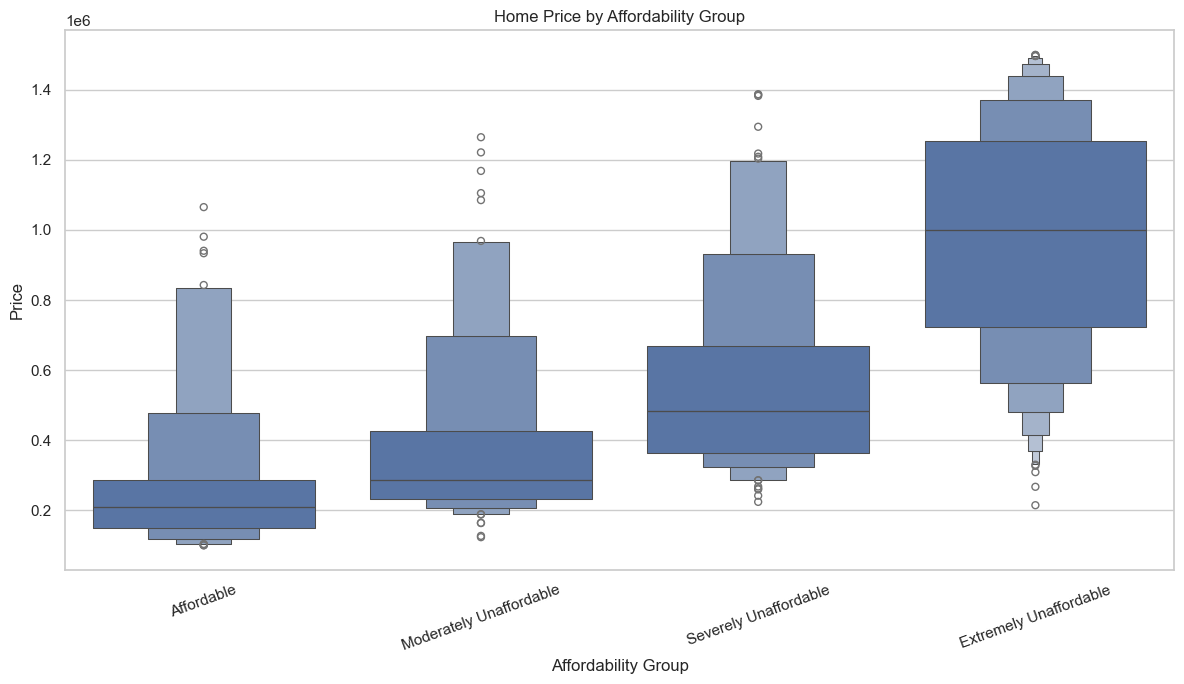

In [544]:
#Affordibility Plot

plt.figure(figsize=(12, 7))
sns.boxenplot(
    data=master_df[master_df["affordability_group"] != "Income Data Missing"],
    x="affordability_group",
    y="price",
    order=["Affordable", "Moderately Unaffordable", "Severely Unaffordable", "Extremely Unaffordable"]
)
plt.title("Home Price by Affordability Group")
plt.xlabel("Affordability Group")
plt.ylabel("Price")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Home prices increase across affordability groups, showing that higher-priced homes tend to be less affordable relative to local income levels.

### MARKET SEGMENTATION

In [545]:
#Market Segments

median_price = master_df["price"].median()
median_income = master_df["avg_household_income"].median()

def get_market_segment(row):
    if pd.isna(row["avg_household_income"]):
        return "Income Data Missing"
    elif row["price"] < median_price and row["avg_household_income"] > median_income:
        return "Undervalued Area"
    elif row["price"] > median_price and row["avg_household_income"] < median_income:
        return "Affordability Pressure"
    elif row["price"] > median_price and row["avg_household_income"] > median_income:
        return "High Price / High Income"
    else:
        return "Lower Price / Lower Income"

master_df["market_segment"] = master_df.apply(get_market_segment, axis=1)

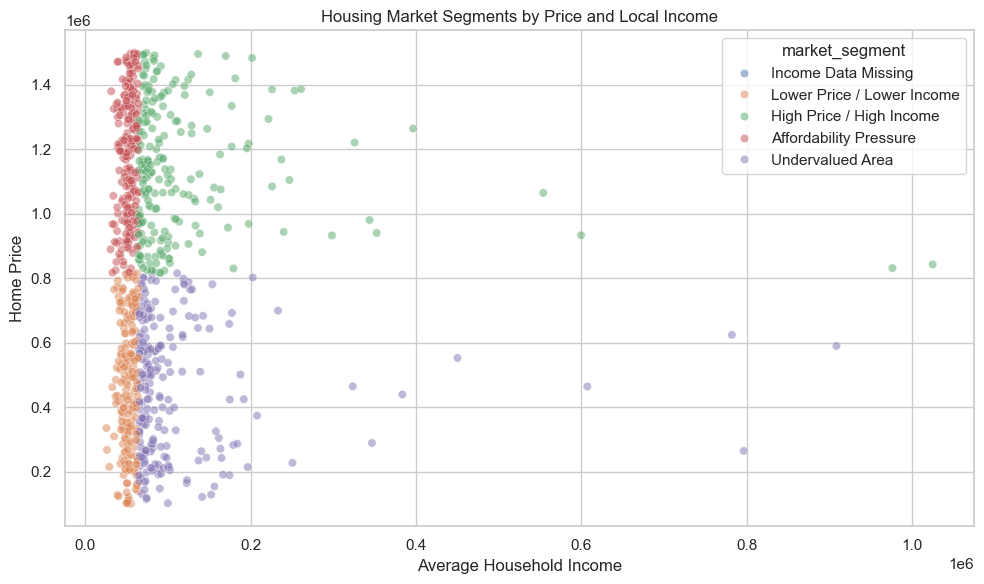

In [546]:
#Market Segment Plot

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=master_df,
    x="avg_household_income",
    y="price",
    hue="market_segment",
    alpha=0.5
)
plt.title("Housing Market Segments by Price and Local Income")
plt.xlabel("Average Household Income")
plt.ylabel("Home Price")
plt.tight_layout()
plt.show()

This visualization highlights how housing prices relate to local income, helping identify areas that may be relatively expensive or more affordable.

### BIG PICTURE RELATIONSHIPS

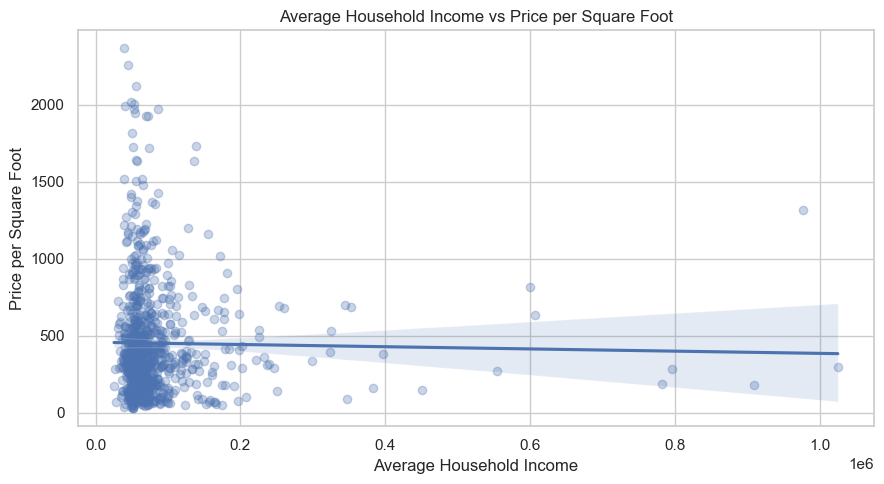

In [547]:
#Price per Sqft vs Income

plt.figure(figsize=(9, 5))
sns.regplot(
    data=master_df,
    x="avg_household_income",
    y="price_per_sqft",
    scatter_kws={"alpha": 0.3}
)
plt.title("Average Household Income vs Price per Square Foot")
plt.xlabel("Average Household Income")
plt.ylabel("Price per Square Foot")
plt.tight_layout()
plt.show()

Price per square foot tends to increase in higher-income areas, indicating that location and neighborhood wealth contribute to housing value beyond property size.

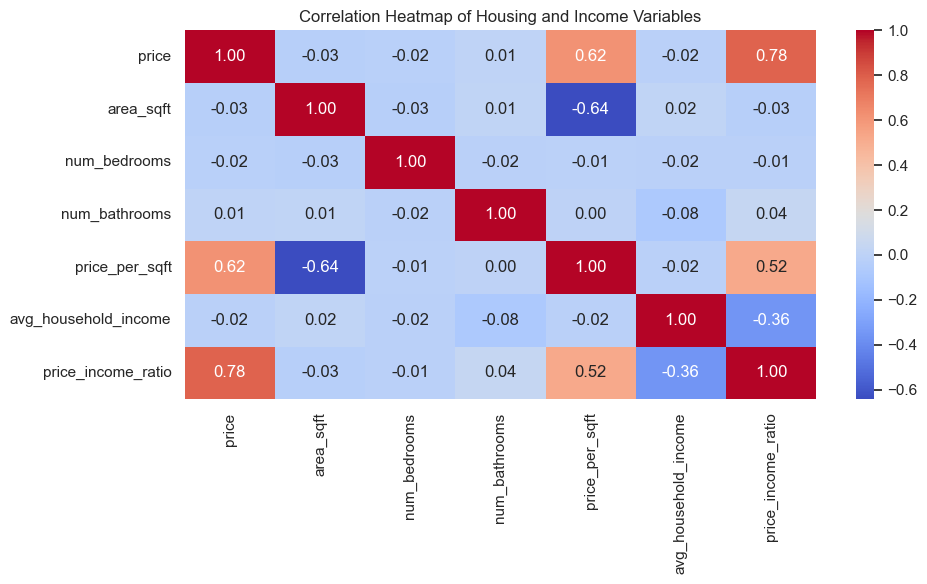

In [548]:
#Correlation Heatmap

cols_for_corr = [
    "price",
    "area_sqft",
    "num_bedrooms",
    "num_bathrooms",
    "price_per_sqft",
    "avg_household_income",
    "price_income_ratio"
]

plt.figure(figsize=(10, 6))
sns.heatmap(master_df[cols_for_corr].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Housing and Income Variables")
plt.tight_layout()
plt.show()

### SQLITE QUERIES

In [549]:
#Check Tables

tables_query = "SELECT name FROM sqlite_master WHERE type='table';"
pd.read_sql(tables_query, conn)

,name
0,master_df
1,property_listings
2,neighborhood_income


In [550]:
#Query 1

query1 = """
SELECT
    h.zipcode,
    COUNT(*) AS listing_count,
    ROUND(AVG(h.price), 2) AS avg_price,
    ROUND(AVG(i.avg_household_income), 2) AS avg_income
FROM property_listings h
LEFT JOIN neighborhood_income i
    ON CAST(h.zipcode AS INTEGER) = i.zip_code
GROUP BY h.zipcode
HAVING COUNT(*) >= 5
ORDER BY avg_price DESC
LIMIT 10;
"""

pd.read_sql(query1, conn)

,zipcode,listing_count,avg_price,avg_income


In [551]:
#Storing master_df

master_df.to_sql("master_df", conn, if_exists="replace", index=False)

3000

In [552]:
#Query 2

query2 = """
SELECT
    market_segment,
    COUNT(*) AS homes,
    ROUND(AVG(price), 2) AS avg_price,
    ROUND(AVG(price_per_sqft), 2) AS avg_price_per_sqft
FROM master_df
GROUP BY market_segment
ORDER BY avg_price DESC;
"""

pd.read_sql(query2, conn)

,market_segment,homes,avg_price,avg_price_per_sqft
0,Affordability Pressure,217,1180525.79,682.12
1,High Price / High Income,207,1136298.27,604.07
2,Income Data Missing,2155,810107.33,461.85
3,Lower Price / Lower Income,206,473569.80,260.09
4,Undervalued Area,215,455132.88,253.27


In [553]:
#Query 3

query3 = """
SELECT
    state_code,
    COUNT(*) AS listing_count,
    ROUND(AVG(price), 2) AS avg_price,
    ROUND(AVG(avg_household_income), 2) AS avg_income
FROM master_df
WHERE avg_household_income IS NOT NULL
GROUP BY state_code
HAVING COUNT(*) >= 10
ORDER BY avg_price DESC;
"""

pd.read_sql(query3, conn)

,state_code,listing_count,avg_price,avg_income
0,MT,10,1117440.10,71434.10
1,IL,39,1046803.28,88834.90
2,CO,10,1018886.30,122017.40
3,SC,12,1009713.25,65721.75
4,MI,39,951485.74,63474.82
5,OK,19,919800.42,60037.95
6,AL,26,913331.92,73815.85
7,SD,15,912842.07,80336.60
8,LA,13,907516.46,52903.77
9,MD,14,872883.00,98006.14


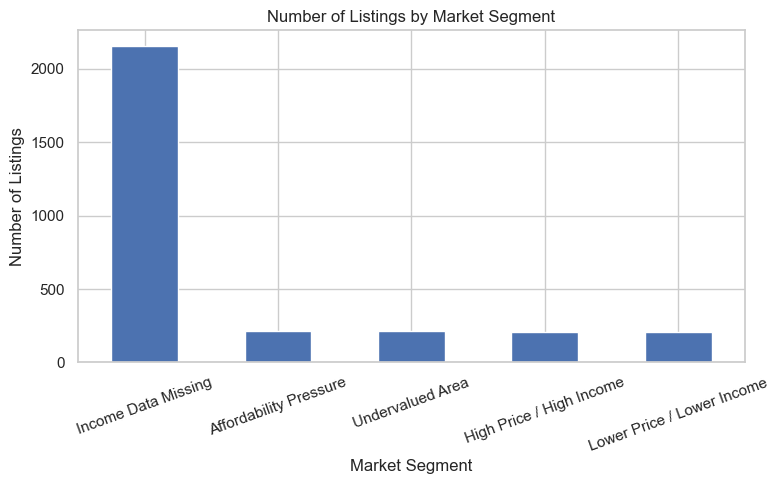

In [554]:
#Market Segment Counts

segment_counts = master_df["market_segment"].value_counts()

plt.figure(figsize=(8,5))
segment_counts.plot(kind="bar")
plt.title("Number of Listings by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Number of Listings")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

This chart shows how listings are distributed across market segments. It helps summarize whether most homes fall into balanced market conditions or whether more listings appear in areas where prices and local income are less aligned.

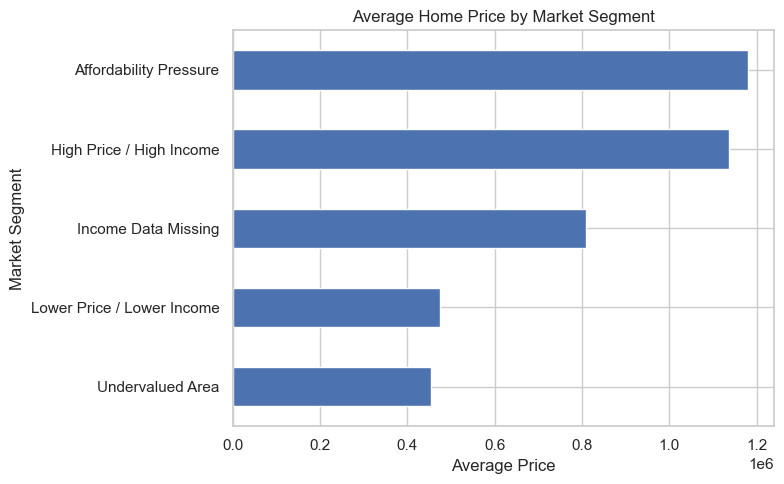

In [555]:
#Average Price by Market Segment

avg_price_by_segment = master_df.groupby("market_segment")["price"].mean().sort_values()

plt.figure(figsize=(8,5))
avg_price_by_segment.plot(kind="barh")
plt.title("Average Home Price by Market Segment")
plt.xlabel("Average Price")
plt.ylabel("Market Segment")
plt.tight_layout()
plt.show()

Average price differs across market segments, showing that local income context adds important perspective beyond home characteristics alone.

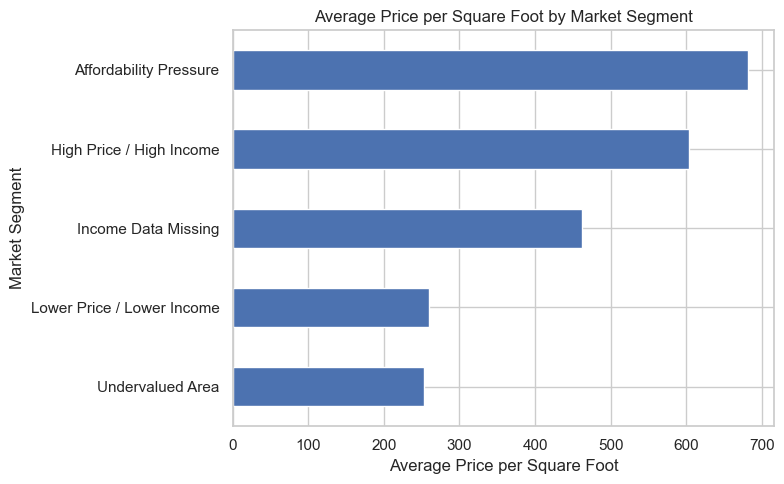

In [556]:
#Average Price per Sq Ft by Market Segment

avg_ppsqft_by_segment = master_df.groupby("market_segment")["price_per_sqft"].mean().sort_values()

plt.figure(figsize=(8,5))
avg_ppsqft_by_segment.plot(kind="barh")
plt.title("Average Price per Square Foot by Market Segment")
plt.xlabel("Average Price per Square Foot")
plt.ylabel("Market Segment")
plt.tight_layout()
plt.show()

This comparison shows how price per square foot changes across segments, helping reveal whether certain areas carry a stronger location premium.

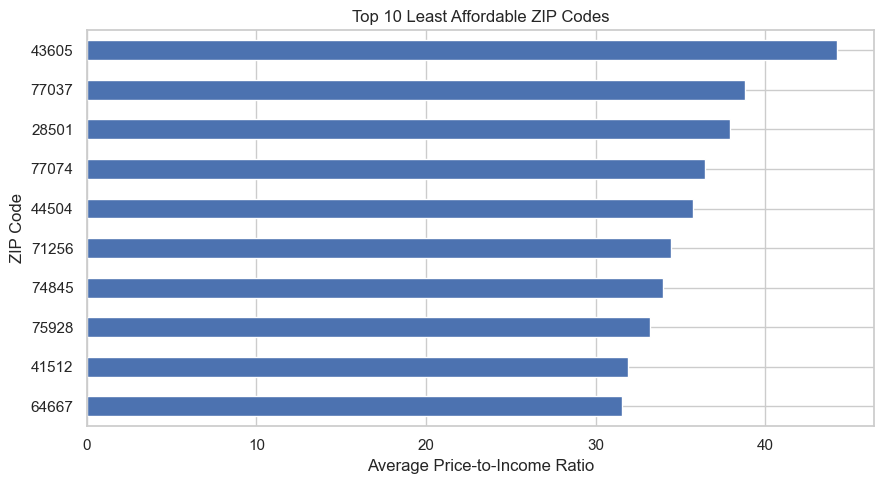

In [557]:
#Top 10 Least Affordable ZIP Codes

least_affordable_zip = (
    master_df.groupby("zipcode")["price_income_ratio"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9,5))
least_affordable_zip.sort_values().plot(kind="barh")
plt.title("Top 10 Least Affordable ZIP Codes")
plt.xlabel("Average Price-to-Income Ratio")
plt.ylabel("ZIP Code")
plt.tight_layout()
plt.show()

The least affordable ZIP codes have the highest average price-to-income ratios, meaning home prices are high relative to local household income.

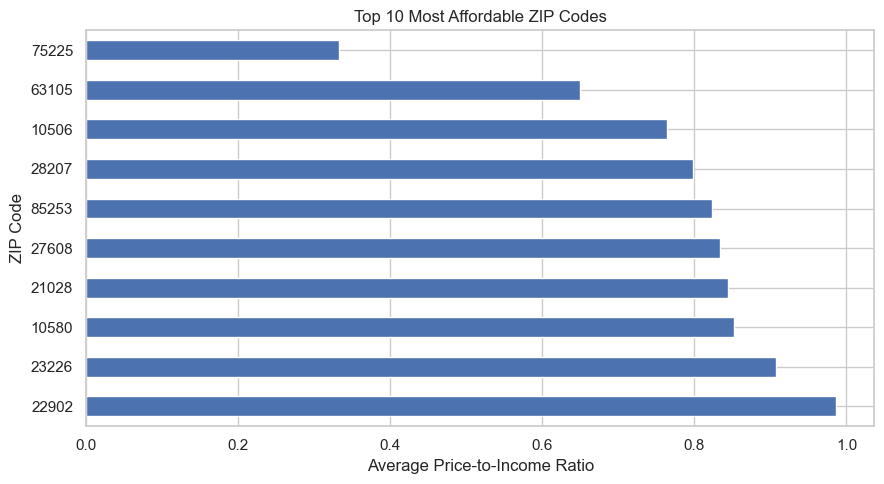

In [558]:
#Top 10 Most Affordable ZIP Codes

most_affordable_zip = (
    master_df.groupby("zipcode")["price_income_ratio"]
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(9,5))
most_affordable_zip.sort_values(ascending=False).plot(kind="barh")
plt.title("Top 10 Most Affordable ZIP Codes")
plt.xlabel("Average Price-to-Income Ratio")
plt.ylabel("ZIP Code")
plt.tight_layout()
plt.show()

These ZIP codes have the lowest price-to-income ratios, suggesting that local housing prices are more aligned with neighborhood income levels.

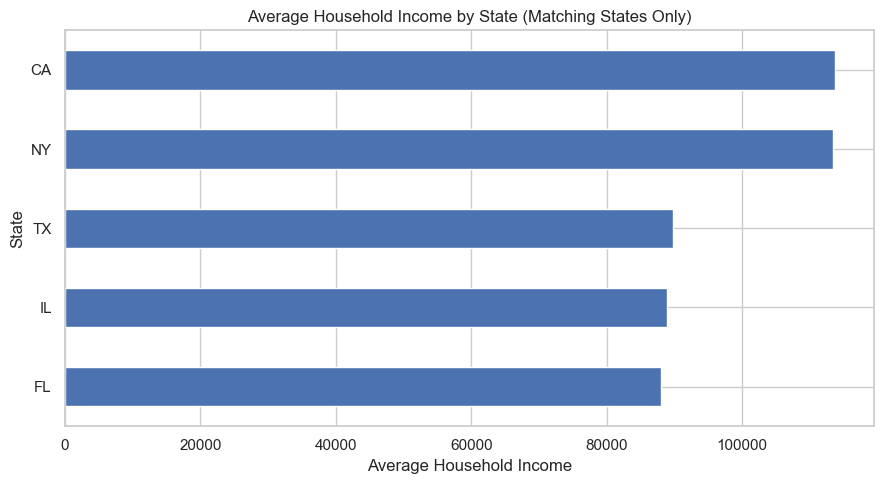

In [559]:
# Get valid states from housing dataset
valid_states = Housing_data["state"].dropna().unique()

# Filter merged dataset
filtered_df = master_df[
    master_df["state_code"].isin(valid_states)
].copy()

# Build aggregation
state_income = (
    filtered_df
    .dropna(subset=["avg_household_income"])
    .groupby("state_code")["avg_household_income"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(9,5))
state_income.sort_values().plot(kind="barh")
plt.title("Average Household Income by State (Matching States Only)")
plt.xlabel("Average Household Income")
plt.ylabel("State")
plt.tight_layout()
plt.show()

This state-level view provides broader geographic context and helps show how the merged dataset captures meaningful variation beyond the ZIP code level.

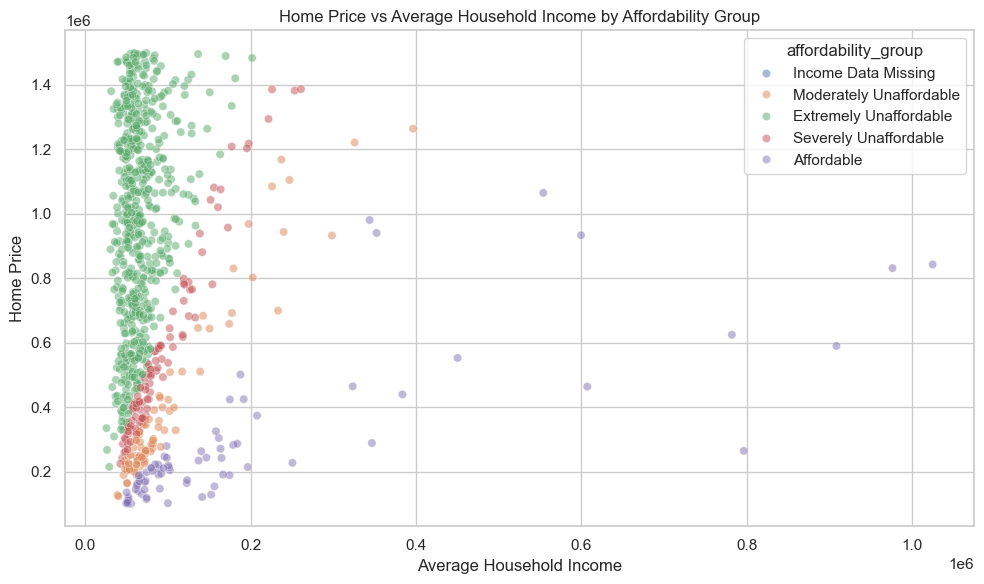

In [560]:
#Price vs Income with Affordability Groups

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=master_df,
    x="avg_household_income",
    y="price",
    hue="affordability_group",
    alpha=0.5
)
plt.title("Home Price vs Average Household Income by Affordability Group")
plt.xlabel("Average Household Income")
plt.ylabel("Home Price")
plt.tight_layout()
plt.show()

This plot gives a second view of affordability by showing how housing prices relate to local income across the affordability groups created earlier.

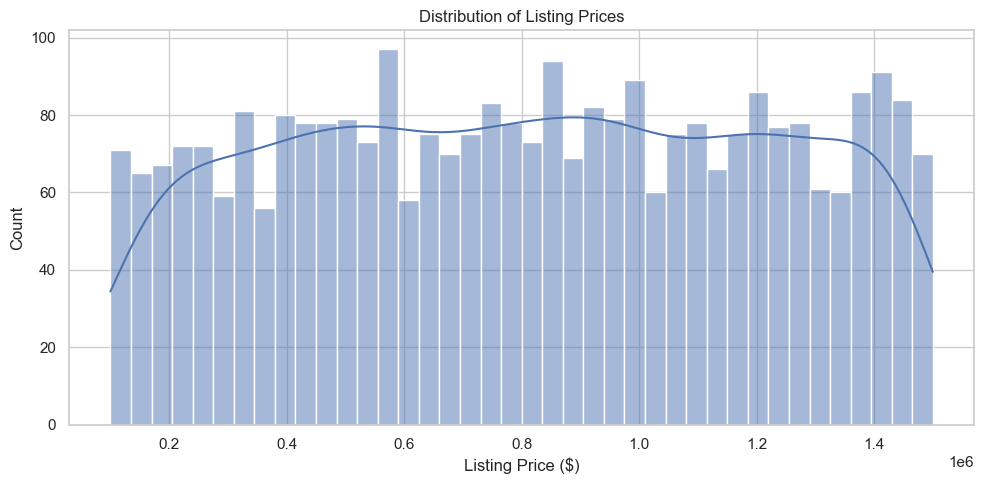

In [561]:
# Distribution of Listing Prices

plt.figure(figsize=(10, 5))
sns.histplot(master_df["price"], bins=40, kde=True)
plt.title("Distribution of Listing Prices")
plt.xlabel("Listing Price ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

This distribution shows that most properties are concentrated within a moderate price range, while a smaller number of listings extend into higher price levels, creating a right-skewed distribution.

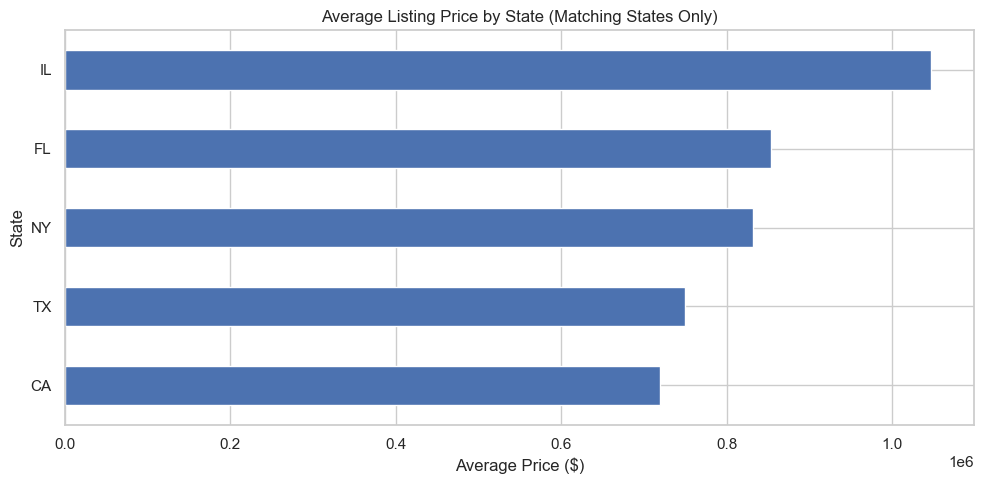

In [562]:
# Get states that exist in BOTH datasets
valid_states = set(Housing_data["state"].dropna().unique())

# Filter master_df to only matching states
filtered_df = master_df[
    master_df["state_code"].isin(valid_states)
].copy()

# Now build the chart
avg_price_state = (
    filtered_df.groupby("state_code")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
avg_price_state.sort_values().plot(kind="barh")
plt.title("Average Listing Price by State (Matching States Only)")
plt.xlabel("Average Price ($)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [563]:
#final summary table

summary_table = pd.DataFrame({
    "Metric": [
        "Total listings analyzed",
        "Listings with matched income data",
        "Average home price",
        "Average price per square foot",
        "Average household income",
        "Average price-to-income ratio"
    ],
    "Value": [
        len(master_df),
        master_df["avg_household_income"].notna().sum(),
        round(master_df["price"].mean(), 2),
        round(master_df["price_per_sqft"].mean(), 2),
        round(master_df["avg_household_income"].mean(), 2),
        round(master_df["price_income_ratio"].mean(), 2)
    ]
})

summary_table

,Metric,Value
0,Total listings analyzed,3000.00
1,Listings with matched income data,845.00
2,Average home price,810859.36
3,Average price per square foot,458.80
4,Average household income,83743.30
5,Average price-to-income ratio,12.53


This summary table provides a concise overview of the final integrated dataset and the key metrics used throughout the analysis.

In [564]:
conn = sqlite3.connect("housing_analysis.db")
pd.read_sql("SELECT COUNT(*) AS total_rows FROM property_listings;", conn)
conn.close()

### Final Analysis and Key Findings

This project combined housing listing data with ZIP code–level income data to better understand how local economic conditions influence housing prices, affordability, and market structure. The analysis focused on four key questions.


### 1. Do higher-income ZIP codes have higher home prices?

The results show a positive relationship between income and housing prices. In general, areas with higher average household income tend to have higher home prices. However, the relationship is not perfectly linear, indicating that other factors such as location desirability, housing supply, and property characteristics also play an important role.


### 2. How does price per square foot vary across income levels?

Price per square foot tends to increase as income rises. Higher-income areas often command a premium not just in total home price, but also in the value of space. This suggests that location and neighborhood characteristics significantly influence how property value is priced beyond just size.


### 3. Are some areas overpriced relative to local income?

Yes, the price-to-income ratio analysis shows that some ZIP codes have significantly higher housing costs relative to local income levels. These areas can be considered less affordable and may indicate demand pressure, limited housing supply, or desirable amenities that drive prices beyond what local income alone would justify.

At the same time, some areas show lower price-to-income ratios, indicating relatively more affordable housing markets where home prices are more aligned with local income.


### 4. What features most strongly influence housing prices?

The analysis shows that housing prices are influenced by a combination of property-level and location-level factors:

- Property size (square footage) is one of the strongest drivers of price.
- Price per square foot provides a normalized view of value and varies significantly by location.
- Number of bedrooms and bathrooms contribute to price but are less influential than total size.
- Local income levels help explain geographic differences in pricing, especially when comparing across ZIP codes.

Overall, housing prices are not determined by a single factor, but rather by the interaction between property characteristics and the economic conditions of the surrounding area.


### Final Summary

By integrating housing and income datasets using SQL, this analysis provides a more complete view of housing affordability and market behavior. The findings highlight that while income is an important driver of housing prices, affordability varies widely across regions, and market dynamics are influenced by both economic and structural factors.

This approach demonstrates how combining multiple datasets can lead to more meaningful insights than analyzing each dataset in isolation.

### Limitations

This analysis uses ZIP-level income data, which reflects general economic conditions rather than the exact financial situation of individual buyers. Additionally, housing prices are based on listing data rather than final sale prices.